## 1. Install Libraries


In [1]:
!pip install -q tensorflow==2.20.0 tensorflow-text==2.20.1 tensorflow-hub numpy scipy pandas seaborn matplotlib scikit-learn nltk pydot graphviz


## Restart Runtime
After the install cell, click **Runtime → Restart runtime**. Then start again from the imports cell below.


## 2. Imports


In [2]:
import os
import io
import sys
import math
import random
import warnings
from pathlib import Path
from string import punctuation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
import tensorflow as tf
import tensorflow_hub as tfh
import tensorflow_text

print("TensorFlow:", tf.__version__)
print("TensorFlow Text imported successfully")


TensorFlow: 2.20.0
TensorFlow Text imported successfully


In [4]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, classification_report
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

import nltk
warnings.filterwarnings("ignore")


## 3. GPU Memory Growth


In [5]:
gpu_devices = tf.config.experimental.list_physical_devices("GPU")
for device in gpu_devices:
    try:
        tf.config.experimental.set_memory_growth(device, True)
    except Exception as exc:
        print("Could not set memory growth:", exc)

print("GPU devices:", gpu_devices)


GPU devices: []


## 4. Mount Google Drive


In [6]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


## 5. Load Dataset


In [7]:
DATA_PATH = "/content/drive/MyDrive/NLP_data_set/ielts_writing_dataset.csv"
OUTPUT_DIR = Path("ielts_traditional_ml_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


## 5.1 Model Evaluation Graph Utilities

These helper functions generate clean model evaluation graphs in sequence after each model. The output folder name is `model_evaluation_graphs` and it does not use any informal wording.

In [8]:
# Clean model evaluation graph utilities.
# Output folder name is programming-style and thesis-friendly.

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve, auc, average_precision_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.preprocessing import label_binarize
from matplotlib.colors import LinearSegmentedColormap

# Print-friendly colormap: white to medium grey, never goes fully black.
LIGHT_GREYS = LinearSegmentedColormap.from_list("light_greys", ["#ffffff", "#a0a0a0"])

MODEL_EVAL_DIR = OUTPUT_DIR / "model_evaluation_graphs"
MODEL_EVAL_DIR.mkdir(exist_ok=True)


def _safe_filename(name):
    name = str(name).lower().replace("+", "plus").replace("±", "pm")
    keep = []
    for ch in name:
        if ch.isalnum():
            keep.append(ch)
        elif ch in [" ", "-", "_", "."]:
            keep.append("_")
    return "".join(keep).strip("_")


def round_to_half_band(values):
    values = np.asarray(values, dtype=float)
    values = np.clip(values, 0, 9)
    return np.round(values * 2) / 2


def to_class_ids(y):
    y = np.asarray(y)
    if y.ndim > 1:
        return np.argmax(y, axis=1).astype(int)
    return y.astype(int)


def plot_loss_history(history, title, file_name):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    if "val_loss" in history.history:
        plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(MODEL_EVAL_DIR / file_name, dpi=300)
    plt.show()


def plot_accuracy_history(history, title, file_name):
    plt.figure(figsize=(8, 5))
    if "accuracy" in history.history:
        plt.plot(history.history["accuracy"], label="Training Accuracy")
    if "val_accuracy" in history.history:
        plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(MODEL_EVAL_DIR / file_name, dpi=300)
    plt.show()


def _classification_probability_matrix(y_pred, n_classes):
    y_pred = np.asarray(y_pred)
    if y_pred.ndim == 2:
        if y_pred.shape[1] == n_classes:
            return y_pred
        fixed = np.zeros((y_pred.shape[0], n_classes), dtype=float)
        cols = min(n_classes, y_pred.shape[1])
        fixed[:, :cols] = y_pred[:, :cols]
        return fixed

    y_ids = y_pred.astype(int)
    probs = np.zeros((len(y_ids), n_classes), dtype=float)
    valid = (y_ids >= 0) & (y_ids < n_classes)
    probs[np.arange(len(y_ids))[valid], y_ids[valid]] = 1.0
    return probs


def _plot_confusion_matrix(cm, display_labels, title, file_name):
    plt.figure(figsize=(8, 6))
    # plt.imshow(cm)
    plt.imshow(cm, cmap=LIGHT_GREYS, vmin=0)   # print-friendly light grayscale
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    ticks = np.arange(len(display_labels))
    plt.xticks(ticks=ticks, labels=display_labels, rotation=45)
    plt.yticks(ticks=ticks, labels=display_labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=8, color="black")
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(MODEL_EVAL_DIR / file_name, dpi=300)
    plt.show()


def _plot_micro_pr_roc(y_true_ids, y_score, classes, title_prefix, file_prefix):
    y_true_bin = label_binarize(y_true_ids, classes=classes)
    if y_true_bin.shape[1] == 1:
        print(f"{title_prefix}: PR/ROC skipped because only one class is present.")
        return np.nan, np.nan

    # Micro Precision-Recall Curve: one clean line for presentation.
    try:
        precision, recall, _ = precision_recall_curve(y_true_bin.ravel(), y_score.ravel())
        ap = average_precision_score(y_true_bin, y_score, average="micro")
        plt.figure(figsize=(7, 5))
        plt.plot(recall, precision, label=f"Micro-average AP = {ap:.2f}")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"{title_prefix} Micro Precision-Recall Curve")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(MODEL_EVAL_DIR / f"{file_prefix}_micro_precision_recall_curve.png", dpi=300)
        plt.show()
    except Exception as e:
        ap = np.nan
        print(f"{title_prefix}: Precision-Recall curve skipped:", e)

    # Micro ROC Curve: one clean line for presentation.
    try:
        fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(7, 5))
        plt.plot(fpr, tpr, label=f"Micro-average AUC = {roc_auc:.2f}")
        plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{title_prefix} Micro ROC Curve")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(MODEL_EVAL_DIR / f"{file_prefix}_micro_roc_curve.png", dpi=300)
        plt.show()
    except Exception as e:
        roc_auc = np.nan
        print(f"{title_prefix}: ROC curve skipped:", e)

    return ap, roc_auc


def evaluate_classification_with_graphs(model_name, y_true, y_pred, class_labels=None, file_prefix=None):
    file_prefix = file_prefix or _safe_filename(model_name)
    y_true_ids = to_class_ids(y_true)
    y_pred_array = np.asarray(y_pred)

    if y_pred_array.ndim == 2:
        y_pred_ids = np.argmax(y_pred_array, axis=1).astype(int)
        n_classes = y_pred_array.shape[1]
    else:
        y_pred_ids = y_pred_array.astype(int)
        n_classes = int(max(y_true_ids.max(), y_pred_ids.max()) + 1)

    classes = np.arange(n_classes)
    if class_labels is None:
        display_labels = [str(c) for c in classes]
    else:
        display_labels = [str(x) for x in list(class_labels)]
        if len(display_labels) != n_classes:
            display_labels = [str(c) for c in classes]

    acc = accuracy_score(y_true_ids, y_pred_ids)
    prec = precision_score(y_true_ids, y_pred_ids, average="weighted", zero_division=0)
    rec = recall_score(y_true_ids, y_pred_ids, average="weighted", zero_division=0)
    f1 = f1_score(y_true_ids, y_pred_ids, average="weighted", zero_division=0)

    print(f"\n{model_name} Classification Results")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-score: {f1:.4f}\n")
    print(classification_report(
        y_true_ids, y_pred_ids,
        labels=classes,
        target_names=display_labels,
        zero_division=0
    ))

    cm = confusion_matrix(y_true_ids, y_pred_ids, labels=classes)
    _plot_confusion_matrix(
        cm,
        display_labels,
        f"{model_name} Confusion Matrix",
        f"{file_prefix}_confusion_matrix.png"
    )

    y_score = _classification_probability_matrix(y_pred_array, n_classes)
    micro_ap, micro_auc = _plot_micro_pr_roc(
        y_true_ids,
        y_score,
        classes,
        model_name,
        file_prefix
    )

    return {
        "Model": model_name,
        "Accuracy": float(acc),
        "Precision": float(prec),
        "Recall": float(rec),
        "F1": float(f1),
        "Micro_AP": float(micro_ap) if not np.isnan(micro_ap) else np.nan,
        "Micro_AUC": float(micro_auc) if not np.isnan(micro_auc) else np.nan,
    }


def _regression_score_matrix(y_pred_raw, class_bands):
    # Higher score means closer to a class band.
    y_pred_raw = np.asarray(y_pred_raw, dtype=float).reshape(-1)
    class_bands = np.asarray(class_bands, dtype=float)
    scores = -np.abs(y_pred_raw[:, None] - class_bands[None, :])
    return scores


def evaluate_regression_with_graphs(model_name, y_true, y_pred_raw, file_prefix=None):
    file_prefix = file_prefix or _safe_filename(model_name)
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred_raw = np.clip(np.asarray(y_pred_raw, dtype=float).reshape(-1), 0, 9)
    y_pred_band = round_to_half_band(y_pred_raw)
    y_true_band = round_to_half_band(y_true)

    mae = mean_absolute_error(y_true, y_pred_raw)
    mse = mean_squared_error(y_true, y_pred_raw)
    rmse = math.sqrt(mse)
    r2 = r2_score(y_true, y_pred_raw)
    exact_rounded_accuracy = np.mean(y_true_band == y_pred_band) * 100

    print(f"\n{model_name} Regression Results")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2: {r2:.4f}")
    print(f"Exact rounded-band accuracy: {exact_rounded_accuracy:.2f}%")

    # Actual vs Predicted scatter graph.
    plt.figure(figsize=(7, 5))
    plt.scatter(y_true, y_pred_raw, alpha=0.6)
    min_val = min(float(np.min(y_true)), float(np.min(y_pred_raw)))
    max_val = max(float(np.max(y_true)), float(np.max(y_pred_raw)))
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", label="Perfect Prediction")
    plt.xlabel("Actual IELTS Score")
    plt.ylabel("Predicted IELTS Score")
    plt.title(f"{model_name} Actual vs Predicted Scores")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(MODEL_EVAL_DIR / f"{file_prefix}_actual_vs_predicted.png", dpi=300)
    plt.show()

    # Single-value error graph for regression models.
    plt.figure(figsize=(7, 5))
    plt.bar(["MAE", "RMSE"], [mae, rmse])
    plt.title(f"{model_name} Error Metrics")
    plt.ylabel("Error Value")
    for i, value in enumerate([mae, rmse]):
        plt.text(i, value + 0.02, f"{value:.3f}", ha="center")
    plt.tight_layout()
    plt.savefig(MODEL_EVAL_DIR / f"{file_prefix}_error_metrics.png", dpi=300)
    plt.show()

    # Confusion matrix after rounding continuous predictions to IELTS half-band.
    class_bands = np.array(sorted(set(y_true_band.tolist() + y_pred_band.tolist())), dtype=float)
    band_to_id = {band: idx for idx, band in enumerate(class_bands)}
    y_true_ids = np.array([band_to_id[v] for v in y_true_band], dtype=int)
    y_pred_ids = np.array([band_to_id[v] for v in y_pred_band], dtype=int)
    display_labels = [str(int(x)) if float(x).is_integer() else str(x) for x in class_bands]

    cm = confusion_matrix(y_true_ids, y_pred_ids, labels=np.arange(len(class_bands)))
    _plot_confusion_matrix(
        cm,
        display_labels,
        f"{model_name} Confusion Matrix After Score Rounding",
        f"{file_prefix}_confusion_matrix.png"
    )

    y_score = _regression_score_matrix(y_pred_raw, class_bands)
    micro_ap, micro_auc = _plot_micro_pr_roc(
        y_true_ids,
        y_score,
        np.arange(len(class_bands)),
        model_name,
        file_prefix
    )

    return {
        "Model": model_name,
        "MAE": float(mae),
        "MSE": float(mse),
        "RMSE": float(rmse),
        "R2": float(r2),
        "Exact_Rounded_Accuracy": float(exact_rounded_accuracy),
        "Micro_AP": float(micro_ap) if not np.isnan(micro_ap) else np.nan,
        "Micro_AUC": float(micro_auc) if not np.isnan(micro_auc) else np.nan,
    }


def plot_deberta_band_tolerance_accuracy(metrics, title, file_name):
    values = [metrics["acc_pm_0_5"], metrics["acc_pm_1_0"]]
    labels = ["Accuracy ±0.5", "Accuracy ±1.0"]
    plt.figure(figsize=(7, 5))
    plt.bar(labels, values)
    plt.title(title)
    plt.ylabel("Accuracy (%)")
    plt.ylim(0, 100)
    for i, value in enumerate(values):
        plt.text(i, value + 1, f"{value:.2f}%", ha="center")
    plt.tight_layout()
    plt.savefig(MODEL_EVAL_DIR / file_name, dpi=300)
    plt.show()

print("Model evaluation graphs will be saved in:", MODEL_EVAL_DIR.resolve())


Model evaluation graphs will be saved in: /content/ielts_traditional_ml_outputs/model_evaluation_graphs


In [9]:
df = pd.read_csv(DATA_PATH)


In [10]:
df.shape


(1435, 9)

In [11]:
df.head()


,Task_Type,Question,Essay,Examiner_Commen,Task_Response,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall
0,1,The bar chart below describes some changes abo...,"Between 1995 and 2010, a study was conducted r...",NaN,NaN,NaN,NaN,NaN,5.5
1,2,Rich countries often give money to poorer coun...,Poverty represents a worldwide crisis. It is t...,NaN,NaN,NaN,NaN,NaN,6.5
2,1,The bar chart below describes some changes abo...,The left chart shows the population change hap...,NaN,NaN,NaN,NaN,NaN,5.0
3,2,Rich countries often give money to poorer coun...,Human beings are facing many challenges nowada...,NaN,NaN,NaN,NaN,NaN,5.5
4,1,The graph below shows the number of overseas v...,Information about the thousands of visits from...,NaN,NaN,NaN,NaN,NaN,7.0


## 6. Missing Values


In [12]:
missing_values = df.isna().sum()
missing_values


,0
Task_Type,0
Question,0
Essay,0
Examiner_Commen,1373
Task_Response,1435
Coherence_Cohesion,1435
Lexical_Resource,1435
Range_Accuracy,1435
Overall,0


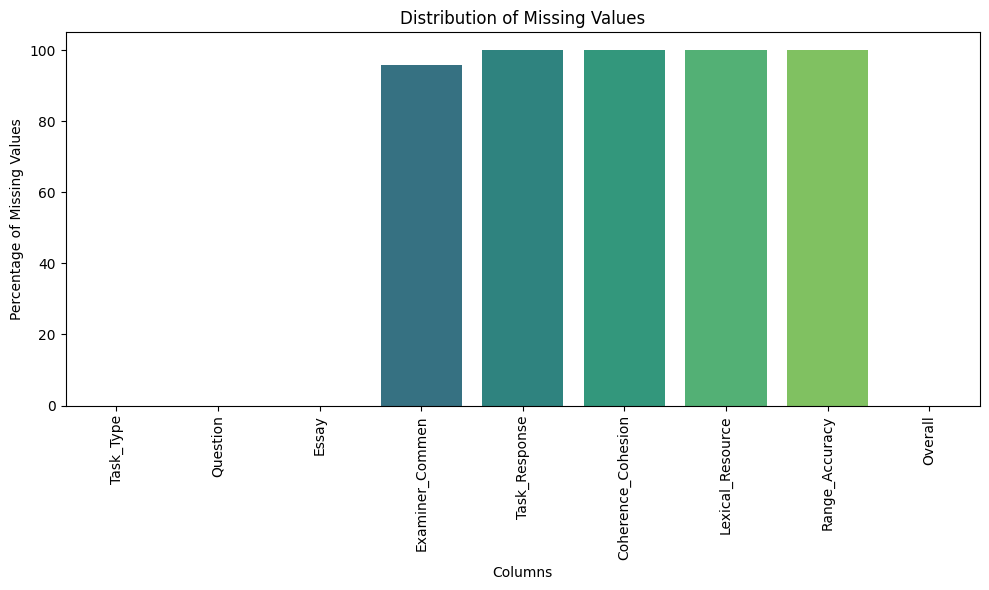

In [13]:
missing_distribution = missing_values / len(df) * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_distribution.index, y=missing_distribution.values, palette="viridis")
plt.title("Distribution of Missing Values")
plt.xlabel("Columns")
plt.ylabel("Percentage of Missing Values")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "missing_values_distribution.png", dpi=300)
plt.show()


## 7. Drop Unused Columns


In [14]:
columns_to_drop = [
    "Examiner_Commen",
    "Task_Response",
    "Coherence_Cohesion",
    "Lexical_Resource",
    "Range_Accuracy",
]

df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])


In [15]:
df = df.dropna(subset=["Essay", "Overall"]).reset_index(drop=True)
df["Essay"] = df["Essay"].astype(str)
df["Overall"] = df["Overall"].astype(float)


In [16]:
df.shape


(1435, 4)

In [17]:
df.head()


,Task_Type,Question,Essay,Overall
0,1,The bar chart below describes some changes abo...,"Between 1995 and 2010, a study was conducted r...",5.5
1,2,Rich countries often give money to poorer coun...,Poverty represents a worldwide crisis. It is t...,6.5
2,1,The bar chart below describes some changes abo...,The left chart shows the population change hap...,5.0
3,2,Rich countries often give money to poorer coun...,Human beings are facing many challenges nowada...,5.5
4,1,The graph below shows the number of overseas v...,Information about the thousands of visits from...,7.0


## 8. Linear Regression Baseline


In [18]:
def preprocess_data_for_lr(dataframe, vectorizer_type):
    X_text = dataframe["Essay"].astype(str)
    y_score = dataframe["Overall"].astype(float)

    if vectorizer_type == "tfidf":
        vectorizer = TfidfVectorizer()
    elif vectorizer_type == "count":
        vectorizer = CountVectorizer()
    else:
        raise ValueError("vectorizer_type must be tfidf or count")

    X_vectorized = vectorizer.fit_transform(X_text)
    return train_test_split(X_vectorized, y_score, test_size=0.2, random_state=42), vectorizer


In [19]:
linear_results = []


In [20]:
for vectorizer_type in ["tfidf", "count"]:
    print(f"Using {vectorizer_type} Vectorizer")
    (X_train_lr, X_test_lr, y_train_lr, y_test_lr), lr_vectorizer = preprocess_data_for_lr(df, vectorizer_type)

    lr = LinearRegression()
    lr.fit(X_train_lr, y_train_lr)
    y_pred_lr = lr.predict(X_test_lr)

    mse = mean_squared_error(y_test_lr, y_pred_lr)
    mae = mean_absolute_error(y_test_lr, y_pred_lr)
    rmse = math.sqrt(mse)
    r2 = r2_score(y_test_lr, y_pred_lr)

    print("Linear Regression")
    print("MSE:", mse)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R-squared:", r2)

    linear_results.append({
        "Model": f"Linear Regression + {vectorizer_type.upper()}",
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
    })


Using tfidf Vectorizer
Linear Regression
MSE: 0.8698093652366341
MAE: 0.6821627732276261
RMSE: 0.9326357087505465
R-squared: 0.16192042573269405
Using count Vectorizer
Linear Regression
MSE: 1.0065191859142204
MAE: 0.7357582829206061
RMSE: 1.0032542977302517
R-squared: 0.03019764498238442


In [21]:
linear_results_df = pd.DataFrame(linear_results)
linear_results_df


,Model,MAE,MSE,RMSE,R2
0,Linear Regression + TFIDF,0.682163,0.869809,0.932636,0.161920
1,Linear Regression + COUNT,0.735758,1.006519,1.003254,0.030198


## 9. Final TF-IDF Linear Regression Model


In [22]:
X = df["Essay"].astype(str)
y = df["Overall"].astype(float)

tfidf_vectorizer = TfidfVectorizer()
X_vectorized = tfidf_vectorizer.fit_transform(X)


In [23]:
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_vectorized, y, test_size=0.2, random_state=42
)

trained_lr_model = LinearRegression().fit(X_train_tfidf, y_train_tfidf)


In [24]:
y_pred_tfidf = trained_lr_model.predict(X_test_tfidf)

print("Mean Absolute Error:", mean_absolute_error(y_test_tfidf, y_pred_tfidf))
print("Mean Squared Error:", mean_squared_error(y_test_tfidf, y_pred_tfidf))
print("R-squared:", r2_score(y_test_tfidf, y_pred_tfidf))


Mean Absolute Error: 0.6821627732276261
Mean Squared Error: 0.8698093652366341
R-squared: 0.16192042573269405


### TF-IDF Linear Regression Evaluation Graphs

This section evaluates the final TF-IDF Linear Regression model using actual vs predicted score, MAE/RMSE, confusion matrix after score rounding, micro precision-recall curve, and micro ROC curve.


TF-IDF Linear Regression Regression Results
MAE: 0.6822
MSE: 0.8698
RMSE: 0.9326
R2: 0.1619
Exact rounded-band accuracy: 31.71%


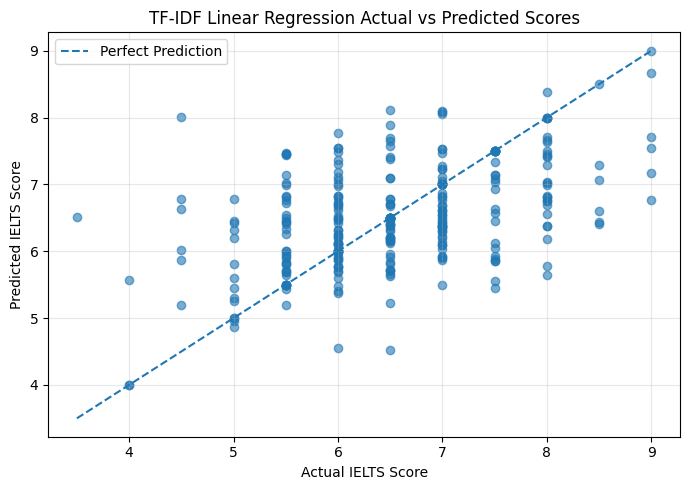

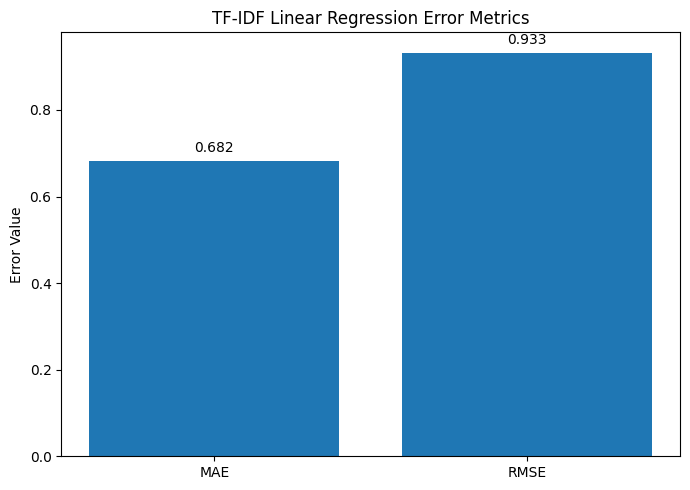

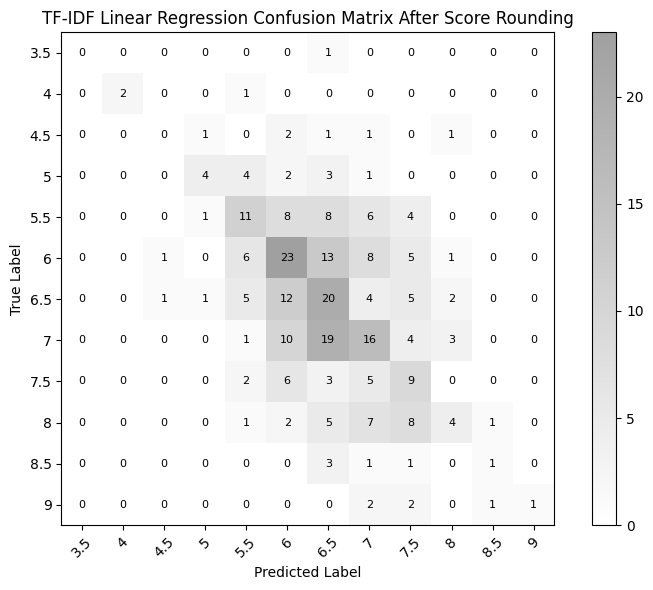

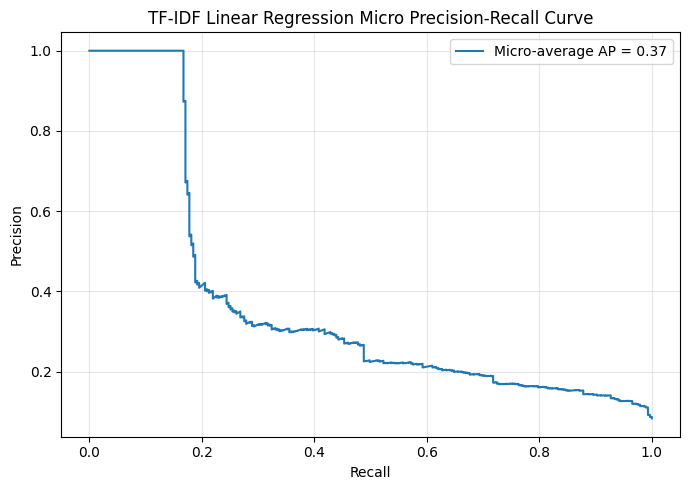

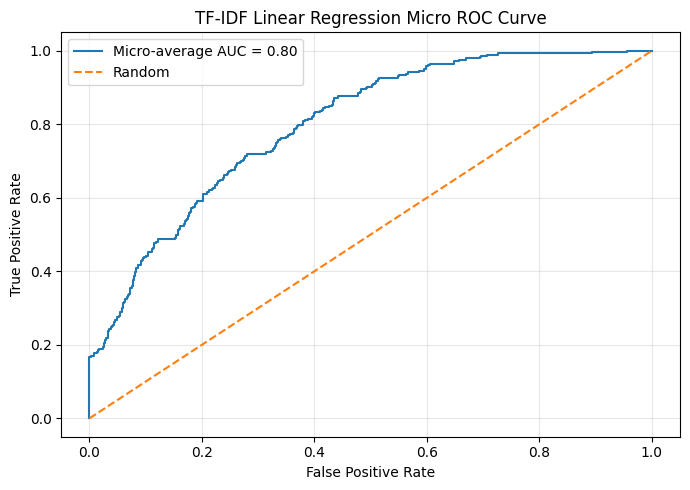

{'Model': 'TF-IDF Linear Regression',
 'MAE': 0.6821627591412383,
 'MSE': 0.8698093652365773,
 'RMSE': 0.9326357087505159,
 'R2': 0.1619204257327489,
 'Exact_Rounded_Accuracy': 31.70731707317073,
 'Micro_AP': 0.3677708877137588,
 'Micro_AUC': 0.7987680713949091}

In [25]:
tfidf_lr_eval = evaluate_regression_with_graphs(
    "TF-IDF Linear Regression",
    y_test_tfidf,
    y_pred_tfidf,
    file_prefix="tfidf_linear_regression"
)
tfidf_lr_eval

In [26]:
new_essay = """Greed, often described as an insatiable desire for more, has been a persistent force throughout human history. It manifests in various forms, from the pursuit of material wealth to the craving for power and influence."""
new_essay_vectorized = tfidf_vectorizer.transform([new_essay])
predicted_grade = trained_lr_model.predict(new_essay_vectorized)
print(f"The predicted grade for the new essay is: {predicted_grade[0]:.3f}")


The predicted grade for the new essay is: 7.205


## 10. NLP Preprocessing Functions


In [27]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("wordnet")
nltk.download("vader_lexicon")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [28]:
def remove_punctuation(data):
    data = str(data)
    for char in punctuation:
        data = data.replace(char, "")
    data = data.replace("\n", " ")
    return data


In [29]:
def mask_numbers(data):
    data = remove_punctuation(str(data))
    words = data.split()
    for idx, word in enumerate(words):
        if word.isnumeric():
            words[idx] = "@"
    return " ".join(words)


In [30]:
def tokenize_text(text):
    tokens = nltk.word_tokenize(str(text))
    return tokens


In [31]:
def handle_special_characters(text):
    import re
    pattern = r"[^a-zA-Z\s]"
    cleaned_text = re.sub(pattern, "", str(text))
    return cleaned_text


In [32]:
def extract_vocab(data):
    vocab_set = set()
    for string in data:
        words = str(string).split()
        vocab_set.update(word.lower() for word in words)
    return vocab_set


In [33]:
def scale_data(data):
    scaled_data = StandardScaler().fit_transform(data)
    return scaled_data


In [34]:
def roundielts(x):
    x = float(x)
    s = x % 1
    if s >= 0.25 and s < 0.5:
        return math.floor(x) + 0.5
    if s < 0.25:
        return math.floor(x)
    if s >= 0.75:
        return math.ceil(x)
    return math.floor(x) + 0.5


## 11. Exploratory Data Analysis


In [35]:
classnum = len(df["Overall"].unique())
classnum


14

In [36]:
df.groupby("Task_Type").agg({"Task_Type": "count"}) if "Task_Type" in df.columns else "Task_Type column not available"


,Task_Type
Task_Type,
1,642
2,793


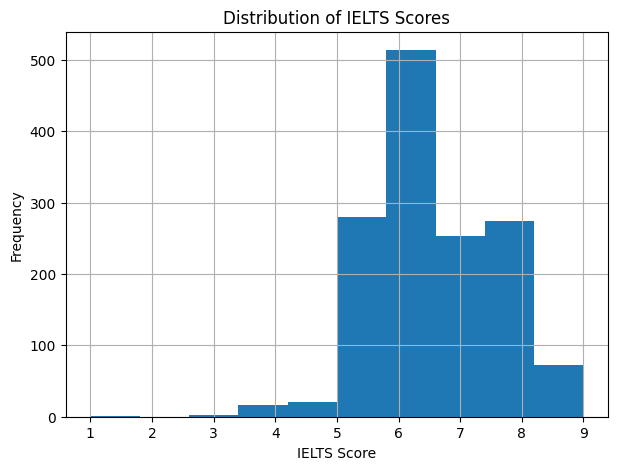

In [37]:
plt.figure(figsize=(7, 5))
plt.hist(df["Overall"])
plt.title("Distribution of IELTS Scores")
plt.xlabel("IELTS Score")
plt.ylabel("Frequency")
plt.grid(True)
plt.savefig(OUTPUT_DIR / "ielts_scores_distribution.png", dpi=300)
plt.show()


In [38]:
df.groupby("Overall").agg({"Overall": "count"})


,Overall
Overall,
1.0,1
3.0,2
3.5,5
4.0,11
4.5,21
5.0,104
5.5,176
6.0,264
6.5,250


In [39]:
df["length"] = df["Essay"].astype(str).apply(lambda x: len(x.split()))
df["length"]


,length
0,125
1,258
2,165
3,298
4,162
...,...
1430,318
1431,220
1432,206
1433,163


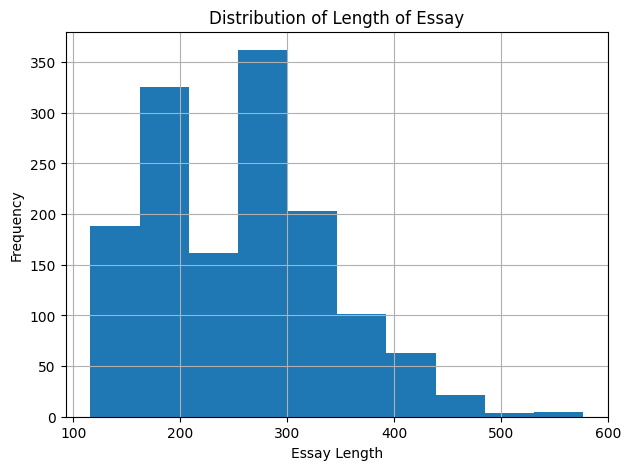

In [40]:
plt.figure(figsize=(7, 5))
plt.hist(df["length"])
plt.title("Distribution of Length of Essay")
plt.xlabel("Essay Length")
plt.ylabel("Frequency")
plt.grid(True)
plt.savefig(OUTPUT_DIR / "length_of_essay_distribution.png", dpi=300)
plt.show()


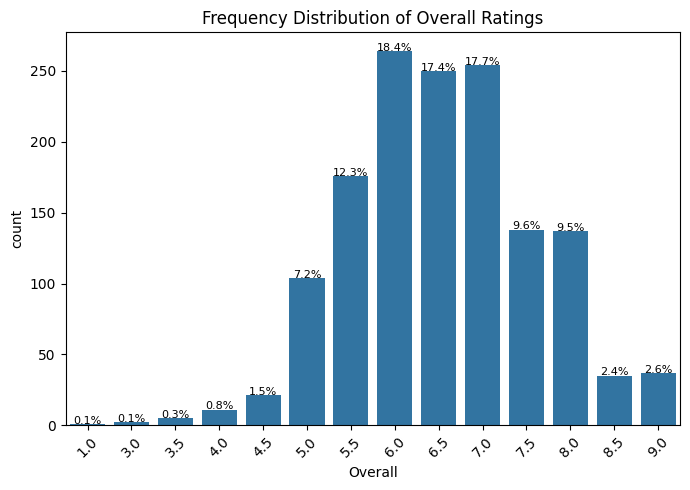

In [41]:
df_sorted = df.sort_values(ascending=True, by="Overall")
plt.figure(figsize=(7, 5))
plot = sns.countplot(data=df_sorted, x="Overall")
for patch in plot.patches:
    height = patch.get_height()
    plot.text(patch.get_x() + patch.get_width() / 2, height + 0.2, f"{height / len(df_sorted) * 100:.1f}%", ha="center", fontsize=8)
plot.set_xticklabels(plot.get_xticklabels(), rotation=45)
plt.title("Frequency Distribution of Overall Ratings")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "essay_distribution_01.png", dpi=300)
plt.show()


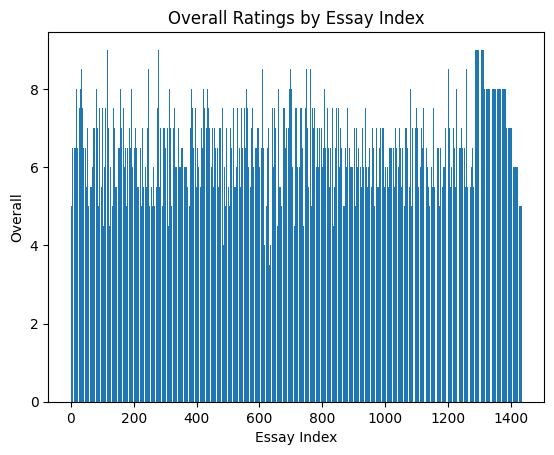

In [42]:
plt.bar(df.index, df["Overall"])
plt.xlabel("Essay Index")
plt.ylabel("Overall")
plt.title("Overall Ratings by Essay Index")
plt.show()


In [43]:
skewness = df["Overall"].skew()
skewness


np.float64(-0.02277710772185054)

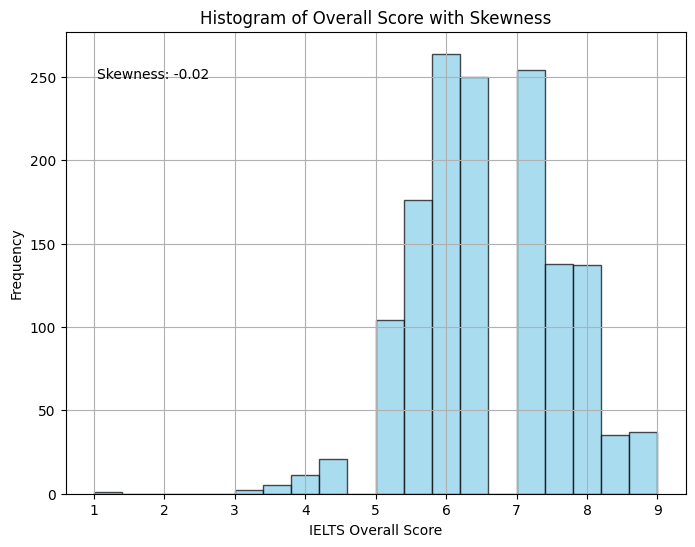

In [44]:
plt.figure(figsize=(8, 6))
plt.hist(df["Overall"], bins=20, color="skyblue", edgecolor="black", alpha=0.7)
plt.xlabel("IELTS Overall Score")
plt.ylabel("Frequency")
plt.title("Histogram of Overall Score with Skewness")
plt.text(0.05, 0.9, f"Skewness: {skewness:.2f}", transform=plt.gca().transAxes)
plt.grid(True)
plt.show()


In [45]:
df.groupby(["Overall"]).agg({"length": "mean"})


,length
Overall,
1.0,279.000000
3.0,198.500000
3.5,140.200000
4.0,214.727273
4.5,220.619048
5.0,234.567308
5.5,229.215909
6.0,248.772727
6.5,248.928000


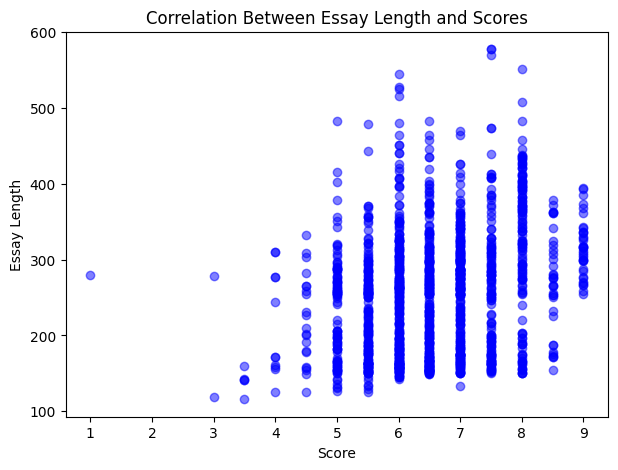

In [46]:
scores = df["Overall"]
lengths = df["length"]
plt.figure(figsize=(7, 5))
plt.scatter(scores, lengths, color="blue", alpha=0.5)
plt.xlabel("Score")
plt.ylabel("Essay Length")
plt.title("Correlation Between Essay Length and Scores")
plt.savefig(OUTPUT_DIR / "corr_essay_distribution_01.png", dpi=300)
plt.show()


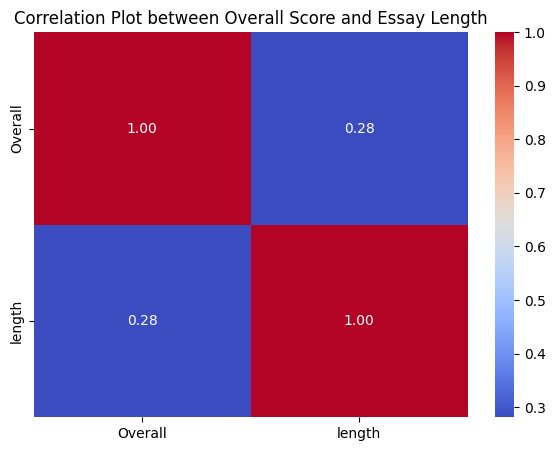

In [47]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[["Overall", "length"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Plot between Overall Score and Essay Length")
plt.savefig(OUTPUT_DIR / "corr_between_essay_length_scores.png", dpi=300)
plt.show()


In [48]:
descriptive_stats = df.describe()
range_score = df_sorted["Overall"].max() - df_sorted["Overall"].min()
skewness = df_sorted["Overall"].skew()
kurtosis = df_sorted["Overall"].kurtosis()

print("Descriptive Statistics:")
print(descriptive_stats)
print("\nAdditional Measures:")
print("Range:", range_score)
print("Skewness:", skewness)
print("Kurtosis:", kurtosis)


Descriptive Statistics:
         Task_Type      Overall       length
count  1435.000000  1435.000000  1435.000000
mean      1.552613     6.550174   256.732404
std       0.497397     1.058237    81.324270
min       1.000000     1.000000   116.000000
25%       1.000000     6.000000   181.000000
50%       2.000000     6.500000   259.000000
75%       2.000000     7.000000   307.000000
max       2.000000     9.000000   577.000000

Additional Measures:
Range: 8.0
Skewness: -0.022777107721850643
Kurtosis: 0.31116209130061945


In [49]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sid = SentimentIntensityAnalyzer()

def get_sentiment_score(essay):
    scores = sid.polarity_scores(str(essay))
    return scores["compound"]

df["sentiment_score"] = df["Essay"].apply(get_sentiment_score)


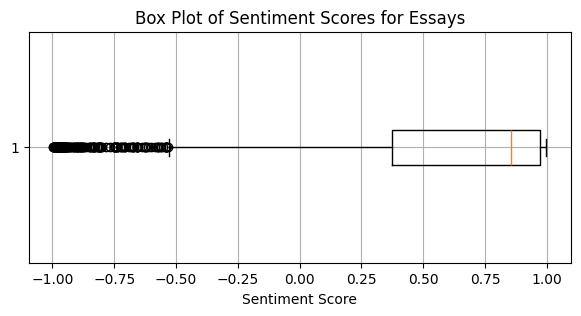

In [50]:
plt.figure(figsize=(7, 3))
plt.boxplot(df["sentiment_score"], vert=False)
plt.xlabel("Sentiment Score")
plt.title("Box Plot of Sentiment Scores for Essays")
plt.grid(True)
plt.savefig(OUTPUT_DIR / "SentimentIntensityAnalyzer.png", dpi=300)
plt.show()


In [51]:
def calculate_vocabulary_size(text):
    words = str(text).split()
    return len(set(words))

vocabulary_sizes = [calculate_vocabulary_size(essay) for essay in df["Essay"]]


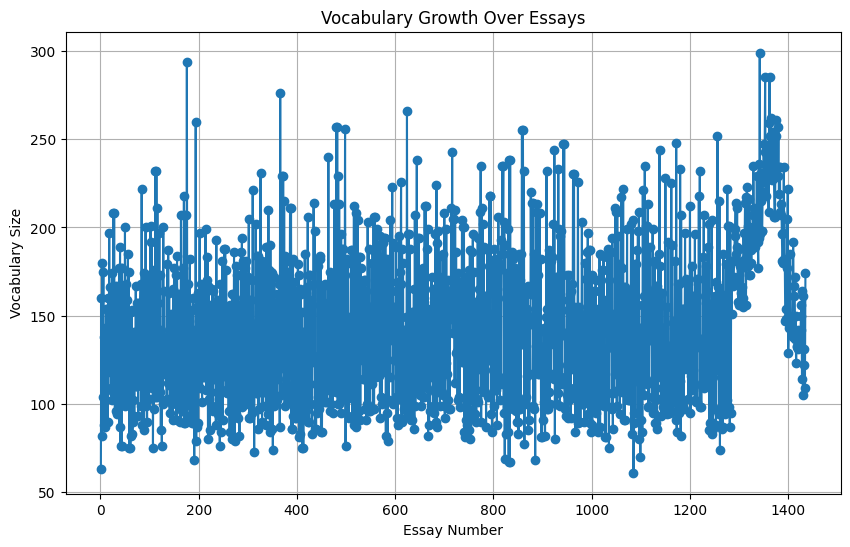

In [52]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(vocabulary_sizes) + 1), vocabulary_sizes, marker="o", linestyle="-")
plt.title("Vocabulary Growth Over Essays")
plt.xlabel("Essay Number")
plt.ylabel("Vocabulary Size")
plt.grid(True)
plt.savefig(OUTPUT_DIR / "vocabulary_growth_essays.png", dpi=300)
plt.show()


## 12. Prepare Data for Classification


In [53]:
df_copy = df.copy()


In [54]:
df_copy["essay_text"] = df_copy["Essay"].apply(mask_numbers)


In [55]:
df_copy["length"] = df_copy["essay_text"].astype(str).apply(lambda text: len(text.split()))


In [56]:
df_copy["Overall2"] = df_copy["Overall"].apply(lambda x: str(x))


In [57]:
if "Task_Type" not in df_copy.columns:
    df_copy["Task_Type"] = 2

X = df_copy[["essay_text", "Task_Type"]]
y = df_copy["Overall2"]
y


,Overall2
0,5.5
1,6.5
2,5.0
3,5.5
4,7.0
...,...
1430,5.0
1431,5.0
1432,5.0
1433,5.0


In [58]:
oe = OrdinalEncoder()
y2 = oe.fit_transform(np.array(y)[:, np.newaxis]).astype(int).ravel()
y2


array([6, 8, 5, ..., 5, 5, 5])

In [59]:
oe.categories_


[array(['1.0', '3.0', '3.5', '4.0', '4.5', '5.0', '5.5', '6.0', '6.5',
        '7.0', '7.5', '8.0', '8.5', '9.0'], dtype=object)]

In [60]:
classnum = len(oe.categories_[0])
y3 = tf.keras.utils.to_categorical(y2, num_classes=classnum).astype("float32")


In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y3, random_state=42, test_size=0.2,
    stratify=y2 if np.min(np.bincount(y2)) >= 2 else None
)
X_train


,essay_text,Task_Type
1127,Usage of drugs is now common in our contempora...,2
898,The provided barr chart depicts the proportion...,1
1187,Rich countries often give money to poorer coun...,2
310,The line chart describes data about the two ye...,1
1144,The bar chart illustrates the performance of t...,1
...,...,...
1095,It is belived that countries are developing fa...,2
1130,The chart illustrates numbers of incidents and...,1
1294,Throughout the history of education learning a...,2
860,The diagrams show the weekly pounds spent on f...,1


In [62]:
max_vocab_length = len(extract_vocab(df_copy["essay_text"]))
max_vocab_length


15268

In [63]:
max_length = int(np.percentile(df_copy["length"], 96))
max_length


411

In [64]:
vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=max_vocab_length,
    output_sequence_length=max_length,
    standardize="lower_and_strip_punctuation"
)


In [65]:
vectorizer.adapt(X_train["essay_text"].astype(str).values)


In [66]:
len(vectorizer.get_vocabulary())


13754

In [67]:
embedding = tf.keras.layers.Embedding(
    input_dim=len(vectorizer.get_vocabulary()),
    output_dim=128,
    mask_zero=True
)


## 13. MLP Classification with USE Embeddings


In [68]:
use_layer = tfh.KerasLayer(
    "https://tfhub.dev/google/universal-sentence-encoder/4",
    trainable=False
)


In [69]:
def make_use_embeddings(text_series, batch_size=8):
    texts = text_series.astype(str).values
    embeddings = []

    for i in range(0, len(texts), batch_size):
        batch_texts = tf.constant(texts[i:i + batch_size], dtype=tf.string)
        batch_embeddings = use_layer(batch_texts)
        embeddings.append(batch_embeddings.numpy())

    return np.vstack(embeddings).astype("float32")


In [70]:
X_train_use = make_use_embeddings(X_train["essay_text"], batch_size=8)
X_test_use = make_use_embeddings(X_test["essay_text"], batch_size=8)

print("Train USE shape:", X_train_use.shape)
print("Test USE shape:", X_test_use.shape)


Train USE shape: (1148, 512)
Test USE shape: (287, 512)


In [71]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

model_hybrid_class_MLP = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(512,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(classnum, activation="softmax", name="outputs"),
], name="HybridClassificationModel")


In [72]:
model_hybrid_class_MLP.summary()


Model: "HybridClassificationModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │         8,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputs (Dense)                 │ (None, 14)             │           462 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,214 (35.99 KB)

 Trainable params: 9,214 (35.99 KB)

 Non-trainable params: 0 (0.00 B)

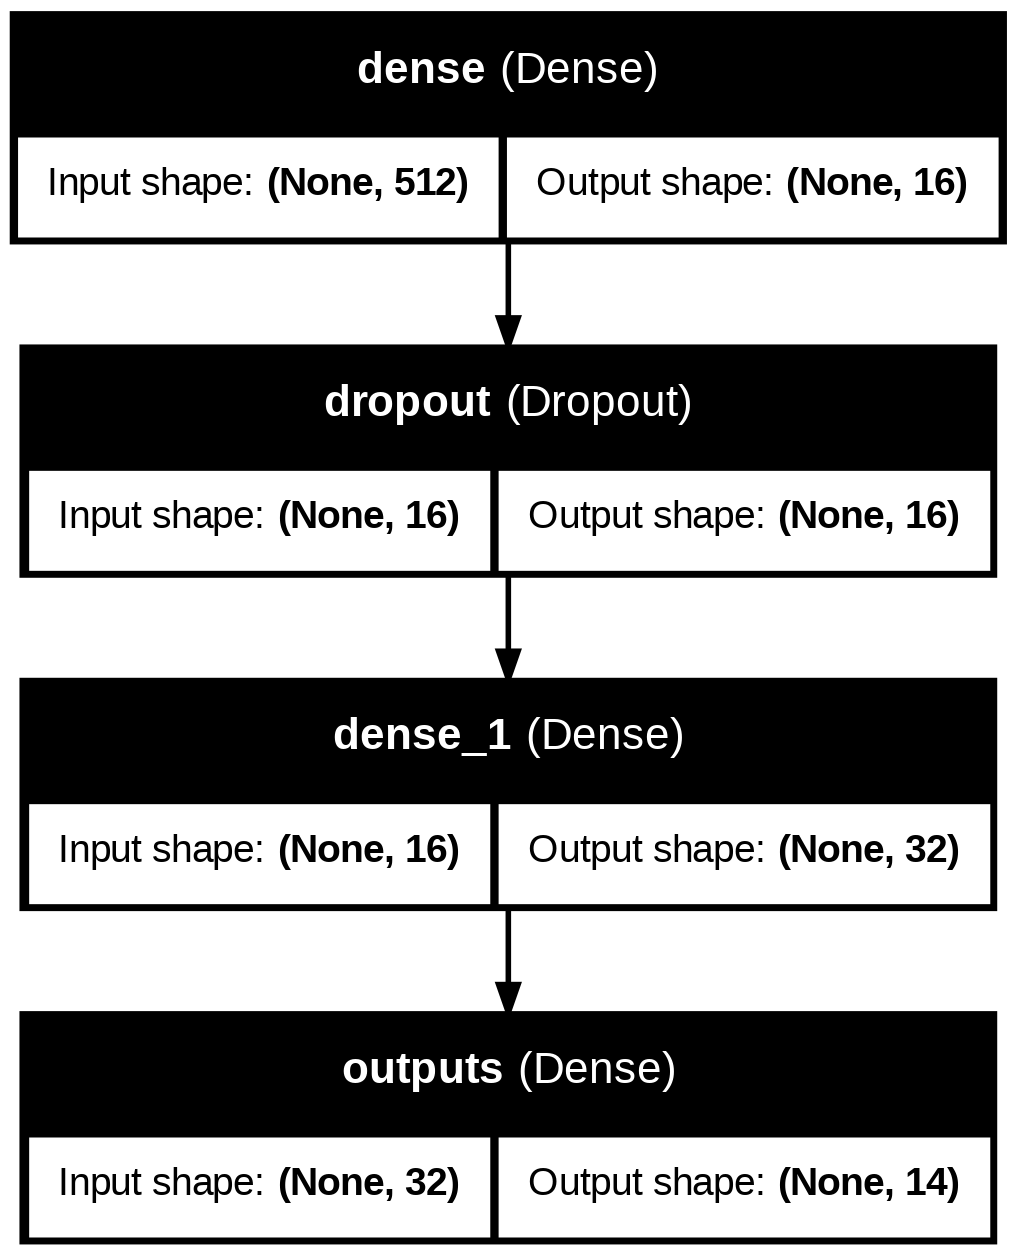

In [73]:
tf.keras.utils.plot_model(
    model_hybrid_class_MLP,
    show_shapes=True,
    show_layer_names=True,
    to_file=str(OUTPUT_DIR / "mlp_classification_model.png")
)


In [74]:
es_cls = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=10,
    mode="max",
    restore_best_weights=True
)


In [75]:
model_hybrid_class_MLP.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)


In [76]:
historyhybridclass = model_hybrid_class_MLP.fit(
    x=X_train_use,
    y=np.asarray(y_train).astype("float32"),
    epochs=150,
    batch_size=32,
    validation_data=(X_test_use, np.asarray(y_test).astype("float32")),
    verbose=1
)


Epoch 1/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.1376 - loss: 2.5894 - val_accuracy: 0.1742 - val_loss: 2.5157
Epoch 2/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1794 - loss: 2.4099 - val_accuracy: 0.1742 - val_loss: 2.3063
Epoch 3/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1794 - loss: 2.2589 - val_accuracy: 0.1742 - val_loss: 2.1745
Epoch 4/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1803 - loss: 2.1933 - val_accuracy: 0.1847 - val_loss: 2.1449
Epoch 5/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2082 - loss: 2.1702 - val_accuracy: 0.1916 - val_loss: 2.1374
Epoch 6/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2021 - loss: 2.1476 - val_accuracy: 0.1916 - val_loss: 2.1320
Epoch 7/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2073 - loss: 2.1523 - val_accuracy: 0.2056 - val_loss: 2.1285
Epoch 8/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1855 - loss: 2.1271 - val_accuracy: 0.1986 - 

### MLP Classification Evaluation Graphs

This section generates the loss graph, accuracy graph, confusion matrix, micro precision-recall curve, and micro ROC curve for the MLP classification model.

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


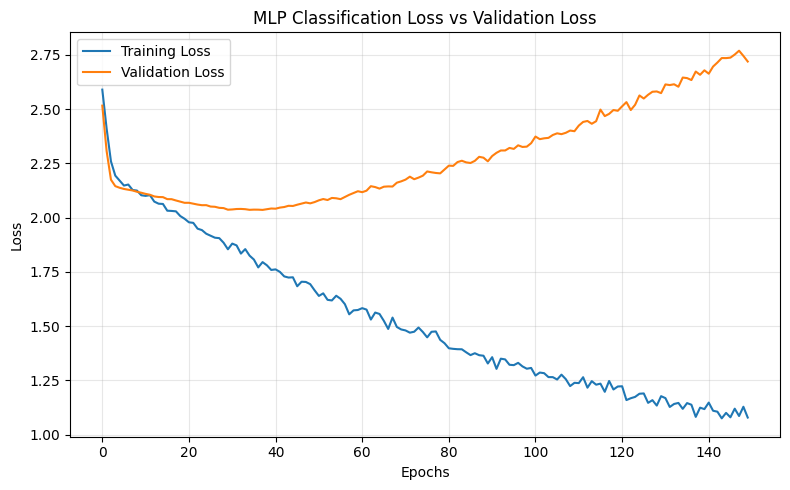

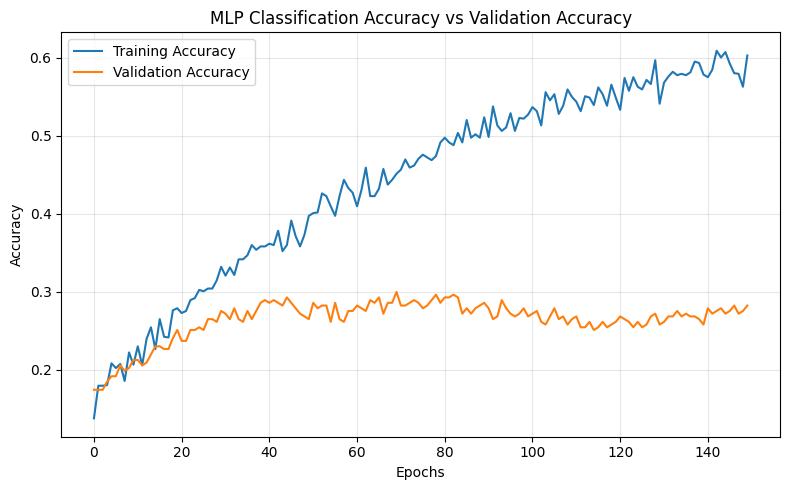


MLP Classification Classification Results
Accuracy: 0.2822
Precision: 0.2781
Recall: 0.2822
F1-score: 0.2716

              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00         0
         3.0       0.00      0.00      0.00         0
         3.5       0.00      0.00      0.00         1
         4.0       0.00      0.00      0.00         3
         4.5       0.00      0.00      0.00         6
         5.0       0.27      0.29      0.28        14
         5.5       0.22      0.16      0.18        38
         6.0       0.22      0.23      0.22        57
         6.5       0.27      0.30      0.29        50
         7.0       0.29      0.34      0.31        53
         7.5       0.27      0.40      0.32        25
         8.0       0.48      0.50      0.49        28
         8.5       0.00      0.00      0.00         6
         9.0       1.00      0.17      0.29         6

    accuracy                           0.28       287
   macro avg       0.22

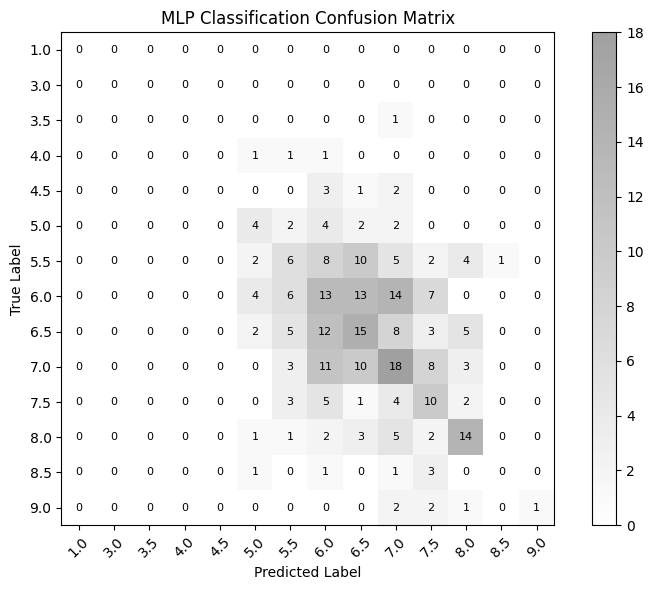

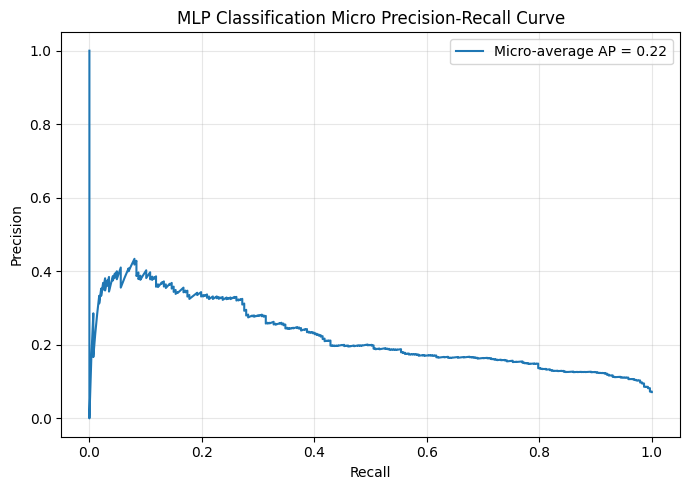

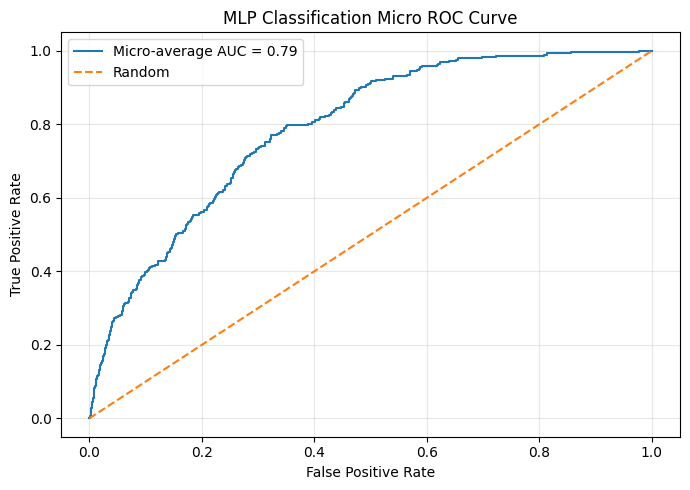

{'Model': 'MLP Classification',
 'Accuracy': 0.28222996515679444,
 'Precision': 0.2781367119317145,
 'Recall': 0.28222996515679444,
 'F1': 0.2716178630290562,
 'Micro_AP': 0.22455318445000877,
 'Micro_AUC': 0.7895100565279881}

In [77]:
# Graphs and evaluation for MLP Classification.
y_pred_mlp = model_hybrid_class_MLP.predict(X_test_use, batch_size=8)

plot_loss_history(
    historyhybridclass,
    "MLP Classification Loss vs Validation Loss",
    "mlp_classification_loss_function_graph.png"
)

plot_accuracy_history(
    historyhybridclass,
    "MLP Classification Accuracy vs Validation Accuracy",
    "mlp_classification_accuracy_graph.png"
)

mlp_eval = evaluate_classification_with_graphs(
    "MLP Classification",
    y_test,
    y_pred_mlp,
    class_labels=oe.categories_[0],
    file_prefix="mlp_classification"
)
mlp_eval

## 14. RNN Classification


In [78]:
input_layer = tf.keras.layers.Input(shape=(), name="Input", dtype=tf.string)
x = vectorizer(input_layer)
x = embedding(x)
x = tf.keras.layers.LSTM(64)(x)
outputs = tf.keras.layers.Dense(classnum, activation="softmax", name="output")(x)
modelrnnclass_RNN = tf.keras.Model(input_layer, outputs, name="RNNClassificationModel")


In [79]:
modelrnnclass_RNN.summary()


Model: "RNNClassificationModel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)  │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 411)       │          0 │ Input[0][0]       │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 411, 128)  │  1,760,512 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 411)       │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     49,408 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 14)        │        910 │ lstm[0][0]        │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,810,830 (6.91 MB)

 Trainable params: 1,810,830 (6.91 MB)

 Non-trainable params: 0 (0.00 B)

In [80]:
modelrnnclass_RNN.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)


In [81]:
es_rnn = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=10,
    mode="max",
    restore_best_weights=True
)


In [82]:
X_train_text_tensor = tf.constant(X_train["essay_text"].astype(str).values, dtype=tf.string)
X_test_text_tensor = tf.constant(X_test["essay_text"].astype(str).values, dtype=tf.string)


In [83]:
# Same training style as old notebook: 150 epochs, no early stopping.
historyrnnclass = modelrnnclass_RNN.fit(
    X_train_text_tensor,
    np.asarray(y_train).astype("float32"),
    epochs=150,
    batch_size=32,
    validation_data=(X_test_text_tensor, np.asarray(y_test).astype("float32")),
    verbose=1
)


Epoch 1/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 17s 414ms/step - accuracy: 0.1794 - loss: 2.3915 - val_accuracy: 0.1986 - val_loss: 2.1369
Epoch 2/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 18s 518ms/step - accuracy: 0.1873 - loss: 2.1384 - val_accuracy: 0.1742 - val_loss: 2.1216
Epoch 3/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 16s 396ms/step - accuracy: 0.2787 - loss: 2.0595 - val_accuracy: 0.2021 - val_loss: 2.0996
Epoch 4/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 402ms/step - accuracy: 0.4634 - loss: 1.7513 - val_accuracy: 0.2718 - val_loss: 2.0822
Epoch 5/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 400ms/step - accuracy: 0.6437 - loss: 1.3035 - val_accuracy: 0.2578 - val_loss: 2.1075
Epoch 6/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 24s 491ms/step - accuracy: 0.7134 - loss: 0.9609 - val_accuracy: 0.2753 - val_loss: 2.0890
Epoch 7/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 402ms/step - accuracy: 0.8223 - loss: 0.7190 - val_accuracy: 0.2578 - val_loss: 2.3006
Epoch 8/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 404ms/step - accuracy: 0.8824 - loss: 0.4463 - 

### RNN Classification Evaluation Graphs

This section generates the loss graph, accuracy graph, confusion matrix, micro precision-recall curve, and micro ROC curve for the RNN classification model.

36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step


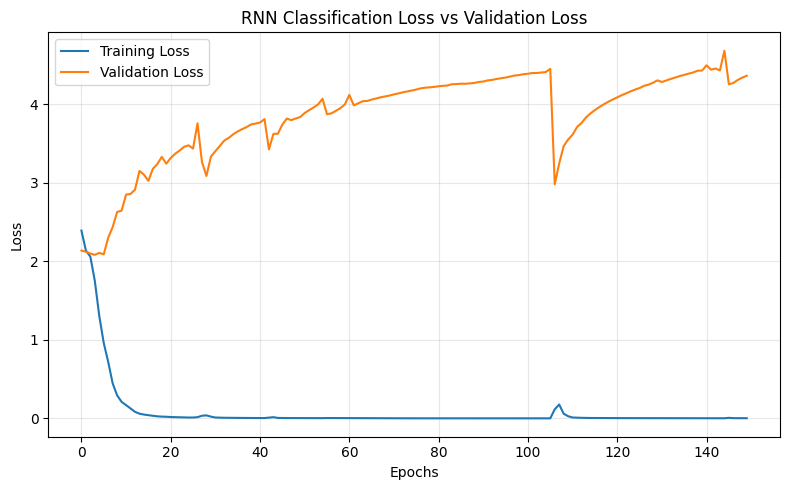

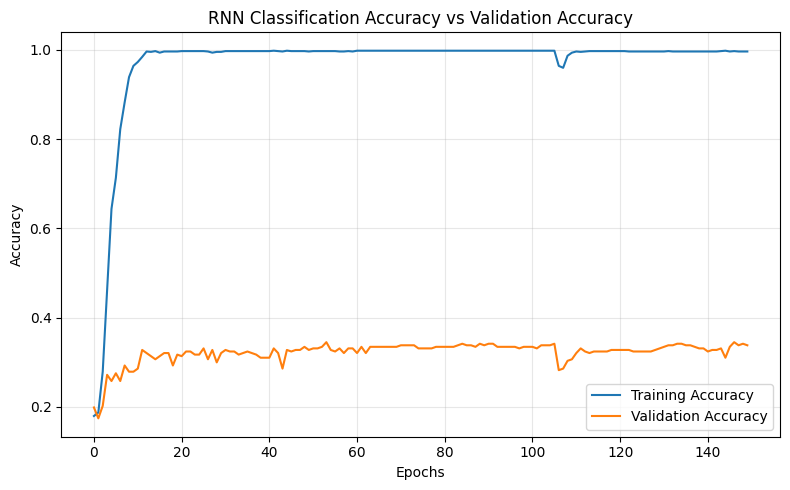


RNN Classification Classification Results
Accuracy: 0.3380
Precision: 0.3361
Recall: 0.3380
F1-score: 0.3343

              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00         0
         3.0       0.00      0.00      0.00         0
         3.5       0.00      0.00      0.00         1
         4.0       0.67      0.67      0.67         3
         4.5       0.00      0.00      0.00         6
         5.0       0.17      0.36      0.23        14
         5.5       0.28      0.21      0.24        38
         6.0       0.36      0.39      0.37        57
         6.5       0.37      0.38      0.37        50
         7.0       0.36      0.32      0.34        53
         7.5       0.33      0.32      0.33        25
         8.0       0.42      0.46      0.44        28
         8.5       0.25      0.17      0.20         6
         9.0       0.33      0.33      0.33         6

    accuracy                           0.34       287
   macro avg       0.25

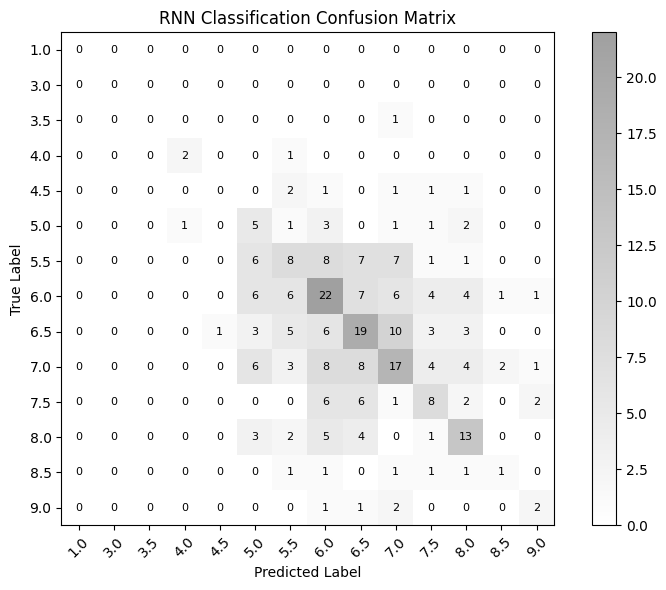

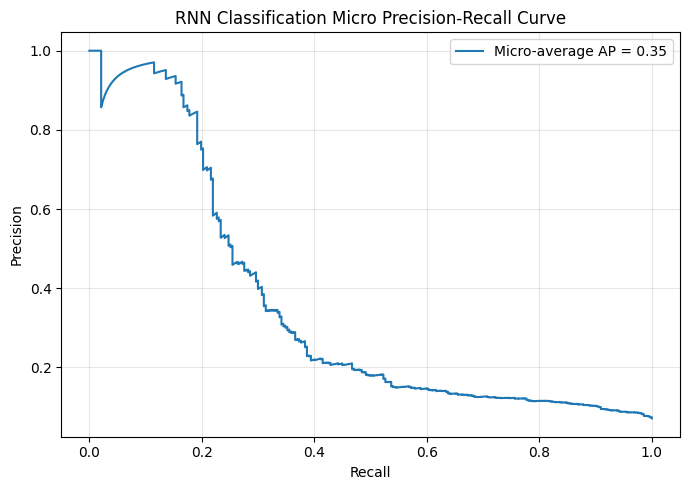

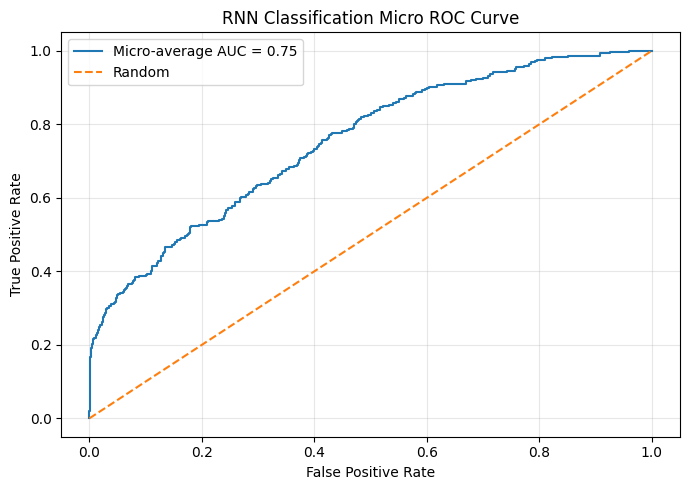

{'Model': 'RNN Classification',
 'Accuracy': 0.33797909407665505,
 'Precision': 0.33612766942756367,
 'Recall': 0.33797909407665505,
 'F1': 0.3342661235005494,
 'Micro_AP': 0.3514684962514394,
 'Micro_AUC': 0.7517381912724821}

In [84]:
# Graphs and evaluation for RNN Classification.
y_pred_rnn = modelrnnclass_RNN.predict(X_test_text_tensor, batch_size=8)

plot_loss_history(
    historyrnnclass,
    "RNN Classification Loss vs Validation Loss",
    "rnn_classification_loss_function_graph.png"
)

plot_accuracy_history(
    historyrnnclass,
    "RNN Classification Accuracy vs Validation Accuracy",
    "rnn_classification_accuracy_graph.png"
)

rnn_eval = evaluate_classification_with_graphs(
    "RNN Classification",
    y_test,
    y_pred_rnn,
    class_labels=oe.categories_[0],
    file_prefix="rnn_classification"
)
rnn_eval

In [85]:
new_sample = "Terrorism, a global scourge, transcends borders, impacting nations far beyond the immediate site of its atrocities."
predictions = modelrnnclass_RNN.predict(tf.constant([new_sample], dtype=tf.string))
predicted_class = int(np.argmax(predictions))
class_names = {idx: value for idx, value in enumerate(oe.categories_[0])}
predicted_class_name = class_names[predicted_class]
print("Predicted Writing Score:", predicted_class_name)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Predicted Writing Score: 5.5


## 15. Hybrid Regression with USE


In [86]:
y_reg = df_copy["Overall"].astype("float32")
X_reg = df_copy[["essay_text", "Task_Type"]]


In [87]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, random_state=42, test_size=0.2
)


In [88]:
X_train_reg_use = make_use_embeddings(X_train_reg["essay_text"], batch_size=8)
X_test_reg_use = make_use_embeddings(X_test_reg["essay_text"], batch_size=8)


In [89]:
es_reg = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    mode="min",
    restore_best_weights=True
)


In [90]:
modelhybridreg = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(512,)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation="linear", name="outputs"),
], name="HybridRegressionModel_USE")


In [91]:
modelhybridreg.compile(
    loss=tf.keras.losses.MeanSquaredError(),
    optimizer=tf.keras.optimizers.Adam(0.001),
    metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")]
)


In [92]:
historyhybridreg = modelhybridreg.fit(
    X_train_reg_use,
    np.asarray(y_train_reg).astype("float32"),
    epochs=150,
    batch_size=32,
    validation_data=(X_test_reg_use, np.asarray(y_test_reg).astype("float32")),
    verbose=1
)


Epoch 1/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 39.5184 - rmse: 6.2864 - val_loss: 33.1824 - val_rmse: 5.7604
Epoch 2/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 27.1703 - rmse: 5.2125 - val_loss: 19.8845 - val_rmse: 4.4592
Epoch 3/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 14.7230 - rmse: 3.8371 - val_loss: 8.8204 - val_rmse: 2.9699
Epoch 4/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2543 - rmse: 2.5009 - val_loss: 3.4942 - val_rmse: 1.8693
Epoch 5/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.5250 - rmse: 1.8775 - val_loss: 2.2118 - val_rmse: 1.4872
Epoch 6/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.6849 - rmse: 1.6386 - val_loss: 1.9709 - val_rmse: 1.4039
Epoch 7/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.7125 - rmse: 1.6470 - val_loss: 1.8337 - val_rmse: 1.3542
Epoch 8/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.4356 - rmse: 1.5607 - val_loss: 1.7268 - val_rmse: 1.3141
Epoch 9/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5

### Hybrid USE Regression Evaluation Graphs

This section evaluates the Hybrid USE Regression model with loss graph, actual vs predicted score graph, error metrics, confusion matrix after score rounding, micro precision-recall curve, and micro ROC curve.

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


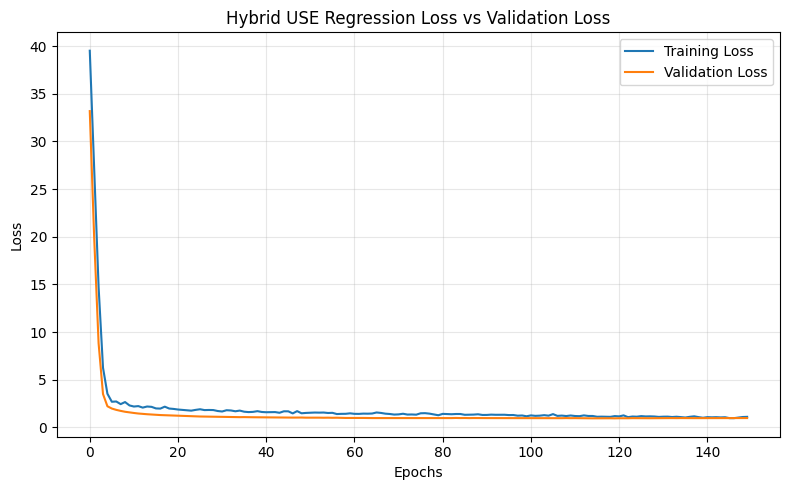


Hybrid USE Regression Regression Results
MAE: 0.7834
MSE: 0.9736
RMSE: 0.9867
R2: 0.0619
Exact rounded-band accuracy: 21.60%


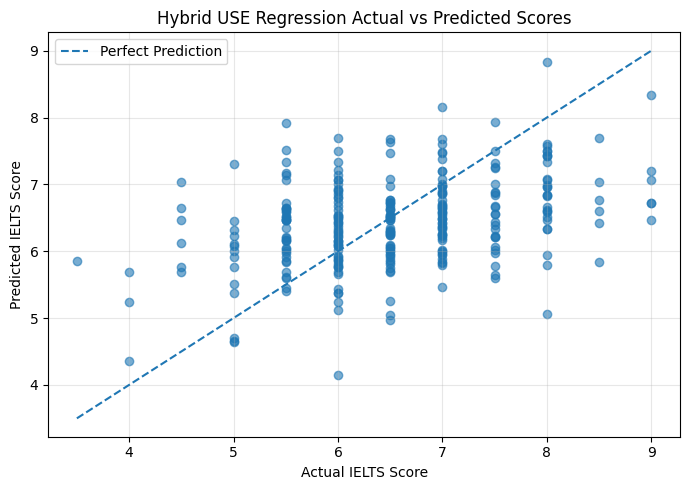

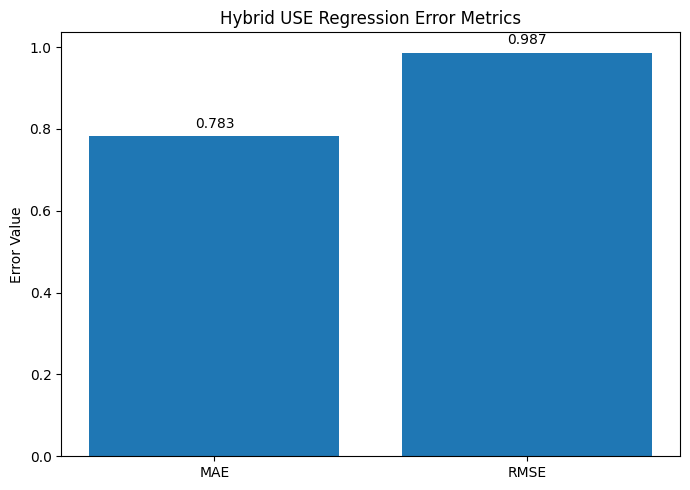

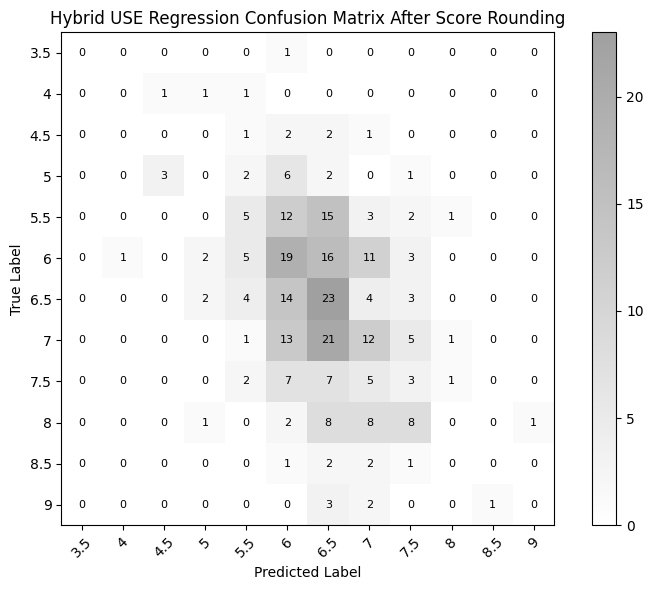

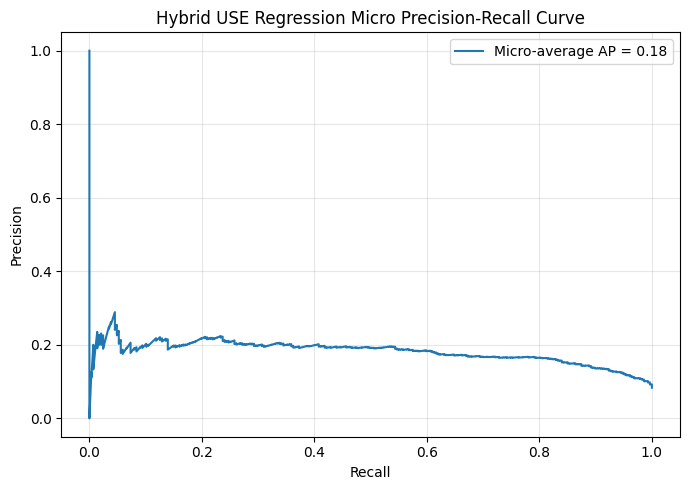

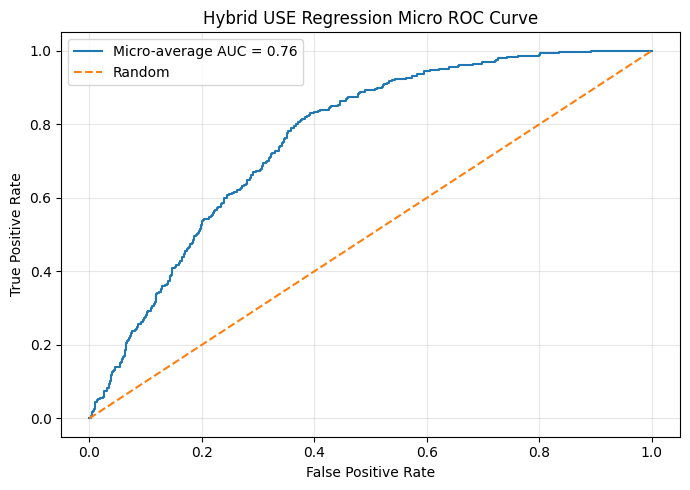

{'Model': 'Hybrid USE Regression',
 'MAE': 0.7833737313539725,
 'MSE': 0.9736195667899828,
 'RMSE': 0.9867216257840824,
 'R2': 0.06189711832812872,
 'Exact_Rounded_Accuracy': 21.602787456445995,
 'Micro_AP': 0.18255039754895208,
 'Micro_AUC': 0.7621104144432095}

In [93]:
# Graphs and evaluation for Hybrid USE Regression.
hybrid_use_pred = modelhybridreg.predict(X_test_reg_use, batch_size=8).reshape(-1)

plot_loss_history(
    historyhybridreg,
    "Hybrid USE Regression Loss vs Validation Loss",
    "hybrid_use_regression_loss_function_graph.png"
)

hybrid_use_eval = evaluate_regression_with_graphs(
    "Hybrid USE Regression",
    y_test_reg,
    hybrid_use_pred,
    file_prefix="hybrid_use_regression"
)
hybrid_use_eval

## 16. Word2Vec-style Regression


In [94]:
def createw2v():
    sentence_inputs = tf.keras.layers.Input(shape=(), dtype=tf.string)
    sentence_tokens = vectorizer(sentence_inputs)
    sentence_embeddings = tf.keras.layers.Embedding(
        input_dim=len(vectorizer.get_vocabulary()),
        output_dim=128,
        mask_zero=True,
        name="word2vec_style_embedding"
    )(sentence_tokens)
    sentence_output = tf.keras.layers.GlobalAveragePooling1D()(sentence_embeddings)
    sentence_output = tf.keras.layers.Dense(16, activation="relu")(sentence_output)
    sentence_output = tf.keras.layers.Dropout(0.5)(sentence_output)
    sentence_model = tf.keras.Model(sentence_inputs, sentence_output)
    return sentence_model


In [95]:
w2v = createw2v()
x = tf.keras.layers.Dense(32, activation="relu")(w2v.output)
outputs = tf.keras.layers.Dense(1, activation="linear", name="outputs")(x)
modelhybridregW2V = tf.keras.Model(inputs=[w2v.input], outputs=outputs, name="HybridRegressionModel_W2V")


In [96]:
modelhybridregW2V.compile(
    loss=tf.keras.losses.MeanSquaredError(),
    optimizer=tf.keras.optimizers.Adam(0.001),
    metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")]
)


In [97]:
modelhybridregW2V_model = modelhybridregW2V.fit(
    tf.constant(X_train_reg["essay_text"].astype(str).values, dtype=tf.string),
    np.asarray(y_train_reg).astype("float32"),
    epochs=150,
    batch_size=32,
    validation_data=(
        tf.constant(X_test_reg["essay_text"].astype(str).values, dtype=tf.string),
        np.asarray(y_test_reg).astype("float32")
    ),
    verbose=1
)


Epoch 1/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 36.8003 - rmse: 6.0663 - val_loss: 19.5175 - val_rmse: 4.4179
Epoch 2/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 9.5207 - rmse: 3.0856 - val_loss: 2.0865 - val_rmse: 1.4445
Epoch 3/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 5.3018 - rmse: 2.3026 - val_loss: 2.9263 - val_rmse: 1.7106
Epoch 4/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 4.3882 - rmse: 2.0948 - val_loss: 4.0876 - val_rmse: 2.0218
Epoch 5/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 3.7184 - rmse: 1.9283 - val_loss: 4.4123 - val_rmse: 2.1005
Epoch 6/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 3.1959 - rmse: 1.7877 - val_loss: 5.7087 - val_rmse: 2.3893
Epoch 7/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 2.9729 - rmse: 1.7242 - val_loss: 5.5377 - val_rmse: 2.3532
Epoch 8/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 2.6342 - rmse: 1.6230 - val_loss: 6.1968 - val_rmse: 2.4893
Epoch 9/150
36/36 ━━━━━━━━━━━━━━━━━━━━

### Word2Vec-style Regression Evaluation Graphs

This section evaluates the Word2Vec-style Regression model with loss graph, actual vs predicted score graph, error metrics, confusion matrix after score rounding, micro precision-recall curve, and micro ROC curve.

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


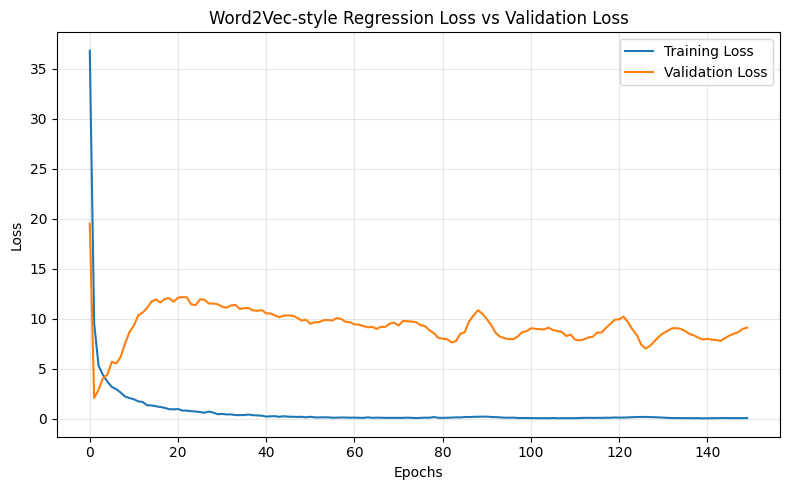


Word2Vec-style Regression Regression Results
MAE: 2.8819
MSE: 9.1204
RMSE: 3.0200
R2: -7.7877
Exact rounded-band accuracy: 0.35%


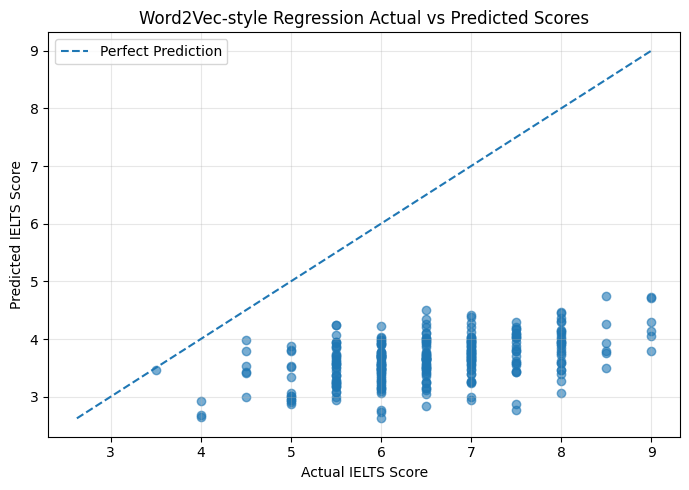

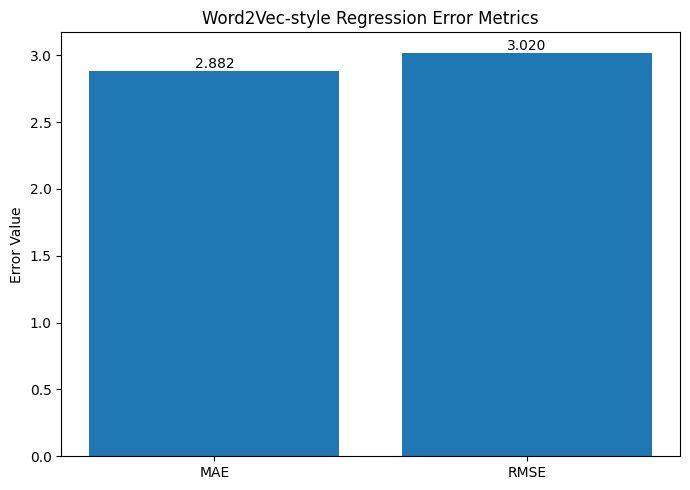

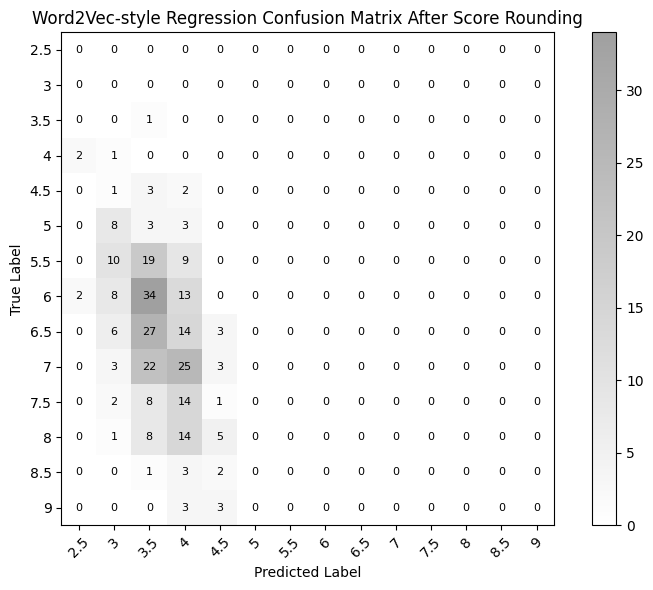

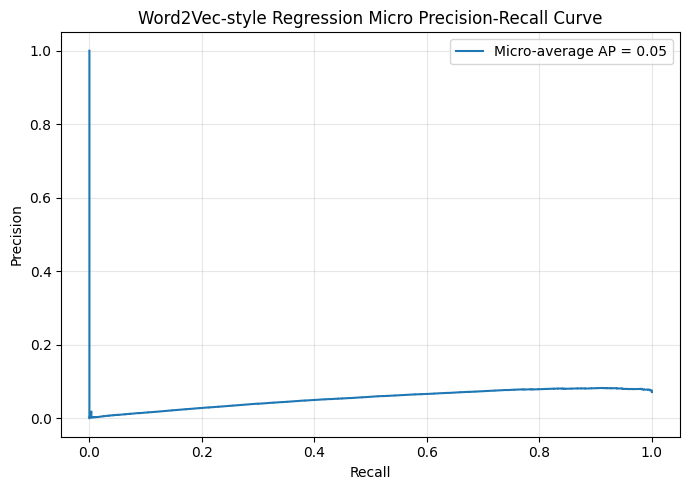

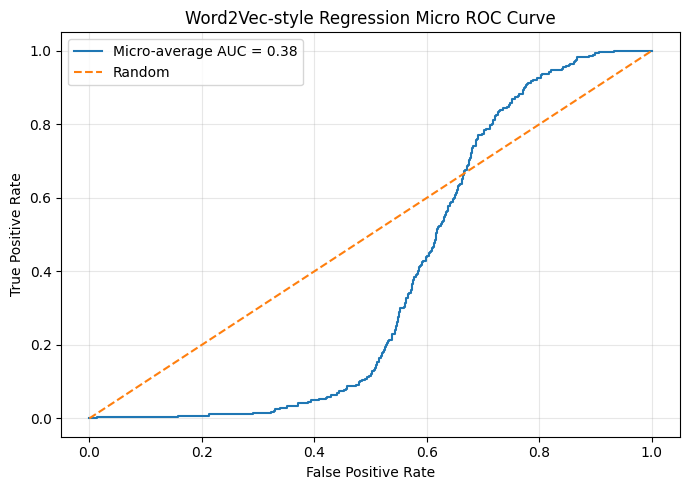

{'Model': 'Word2Vec-style Regression',
 'MAE': 2.881902962196164,
 'MSE': 9.12044604406798,
 'RMSE': 3.0200076231804416,
 'R2': -7.787741134128797,
 'Exact_Rounded_Accuracy': 0.34843205574912894,
 'Micro_AP': 0.05383582839032502,
 'Micro_AUC': 0.3830006994789862}

In [98]:
# Graphs and evaluation for Word2Vec-style Regression.
w2v_pred = modelhybridregW2V.predict(
    tf.constant(X_test_reg["essay_text"].astype(str).values, dtype=tf.string),
    batch_size=8
).reshape(-1)

plot_loss_history(
    modelhybridregW2V_model,
    "Word2Vec-style Regression Loss vs Validation Loss",
    "word2vec_style_regression_loss_function_graph.png"
)

word2vec_eval = evaluate_regression_with_graphs(
    "Word2Vec-style Regression",
    y_test_reg,
    w2v_pred,
    file_prefix="word2vec_style_regression"
)
word2vec_eval

## 17. USE Regression


In [99]:
modelregressionclass = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(512,)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1, activation="linear", name="output"),
], name="PreRegressionModel_USE")


In [100]:
modelregressionclass.compile(
    loss=tf.keras.losses.MeanSquaredError(),
    optimizer=tf.keras.optimizers.Adam(0.001),
    metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")]
)


In [101]:
historyprereg = modelregressionclass.fit(
    X_train_reg_use,
    np.asarray(y_train_reg).astype("float32"),
    epochs=150,
    batch_size=32,
    validation_data=(X_test_reg_use, np.asarray(y_test_reg).astype("float32")),
    verbose=1
)


Epoch 1/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 35.6375 - rmse: 5.9697 - val_loss: 25.0493 - val_rmse: 5.0049
Epoch 2/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 17.2634 - rmse: 4.1549 - val_loss: 9.4344 - val_rmse: 3.0715
Epoch 3/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.8538 - rmse: 2.4195 - val_loss: 3.0166 - val_rmse: 1.7368
Epoch 4/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.3751 - rmse: 1.5411 - val_loss: 2.0480 - val_rmse: 1.4311
Epoch 5/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.8738 - rmse: 1.3689 - val_loss: 1.8583 - val_rmse: 1.3632
Epoch 6/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.7004 - rmse: 1.3040 - val_loss: 1.7057 - val_rmse: 1.3060
Epoch 7/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5713 - rmse: 1.2535 - val_loss: 1.5935 - val_rmse: 1.2623
Epoch 8/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.4719 - rmse: 1.2132 - val_loss: 1.5083 - val_rmse: 1.2281
Epoch 9/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms

### USE Regression Evaluation Graphs

This section evaluates the USE Regression model with loss graph, actual vs predicted score graph, error metrics, confusion matrix after score rounding, micro precision-recall curve, and micro ROC curve.

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


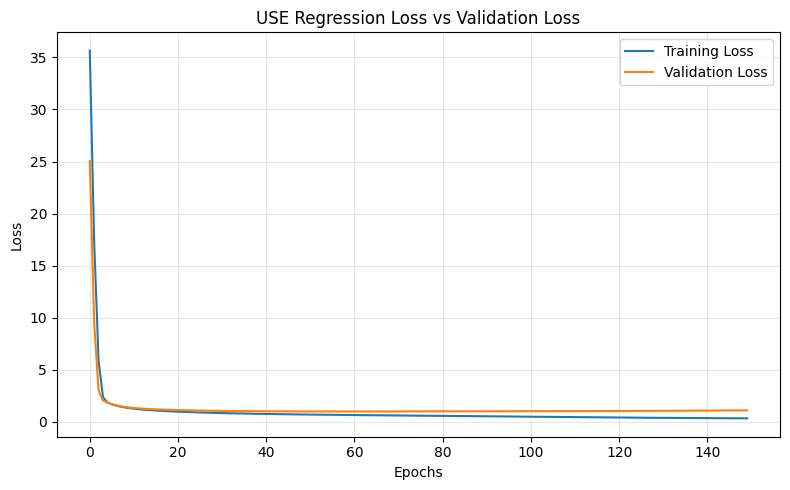


USE Regression Regression Results
MAE: 0.8309
MSE: 1.1136
RMSE: 1.0553
R2: -0.0730
Exact rounded-band accuracy: 20.91%


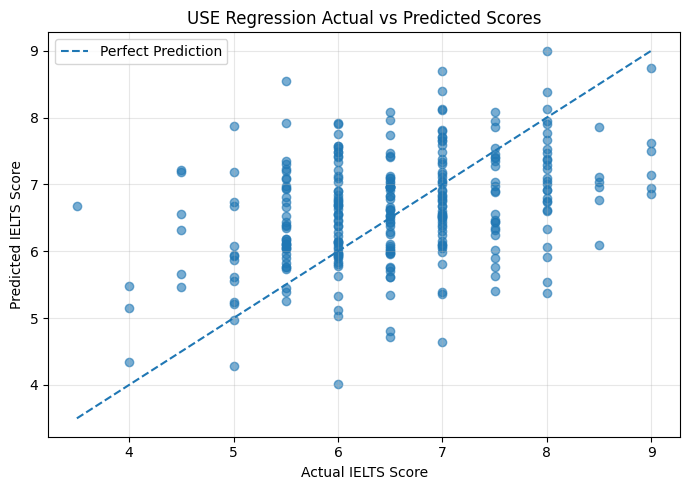

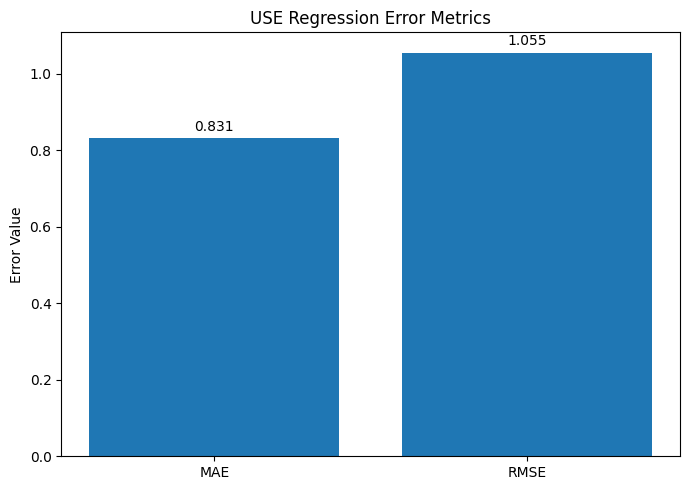

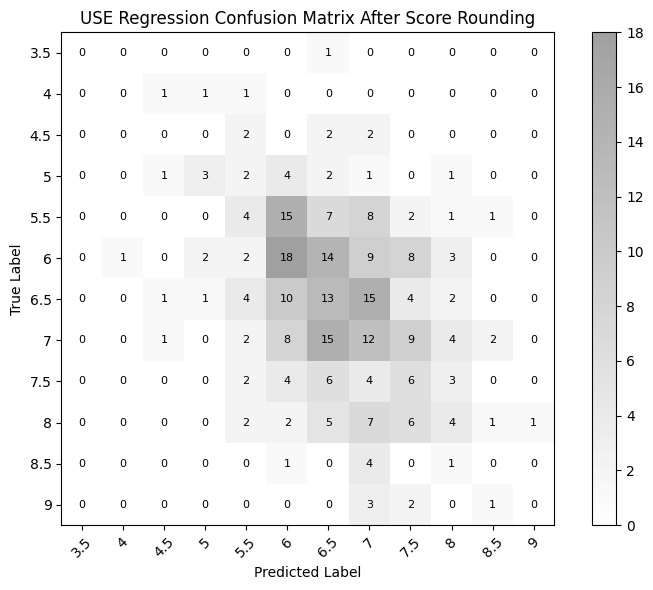

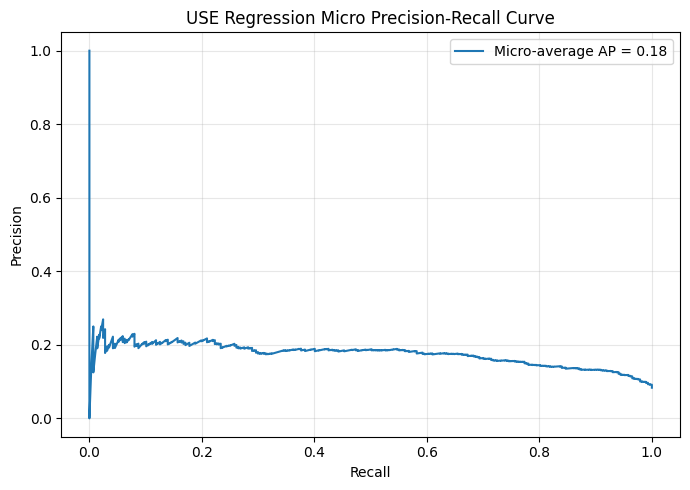

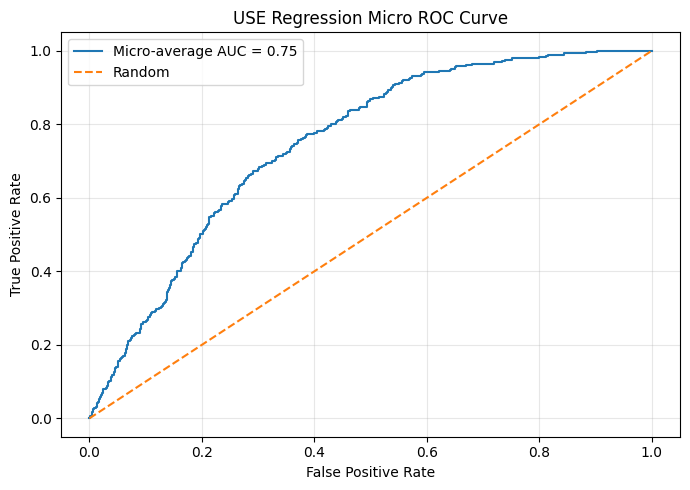

{'Model': 'USE Regression',
 'MAE': 0.8308515831153152,
 'MSE': 1.113596464212142,
 'RMSE': 1.0552708013643428,
 'R2': -0.07297355941734085,
 'Exact_Rounded_Accuracy': 20.905923344947734,
 'Micro_AP': 0.17569653823948375,
 'Micro_AUC': 0.7480307573789345}

In [102]:
# Graphs and evaluation for USE Regression.
use_pred = modelregressionclass.predict(X_test_reg_use, batch_size=8).reshape(-1)

plot_loss_history(
    historyprereg,
    "USE Regression Loss vs Validation Loss",
    "use_regression_loss_function_graph.png"
)

use_eval = evaluate_regression_with_graphs(
    "USE Regression",
    y_test_reg,
    use_pred,
    file_prefix="use_regression"
)
use_eval

## 18. K-Fold Cross Validation


In [103]:
X_all_text = np.array(df_copy["essay_text"].astype(str))
y_all = np.array(df_copy["Overall"].astype("float32"))

k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=1)
val_losses = []


In [104]:
for fold, (train_index, val_index) in enumerate(kf.split(X_all_text), start=1):
    print(f"Fold {fold}/{k}")
    X_fold_train_text = pd.Series(X_all_text[train_index])
    X_fold_val_text = pd.Series(X_all_text[val_index])
    y_fold_train = y_all[train_index]
    y_fold_val = y_all[val_index]

    X_fold_train_use = make_use_embeddings(X_fold_train_text, batch_size=8)
    X_fold_val_use = make_use_embeddings(X_fold_val_text, batch_size=8)

    fold_model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(512,)),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(1, activation="linear")
    ])
    fold_model.compile(optimizer="adam", loss="mean_squared_error")
    fold_model.fit(X_fold_train_use, y_fold_train, epochs=10, batch_size=8, verbose=1)

    y_val_pred = fold_model.predict(X_fold_val_use, batch_size=8).reshape(-1)
    val_loss = mean_squared_error(y_fold_val, y_val_pred)
    val_losses.append(val_loss)
    print("Fold MSE:", val_loss)

avg_val_loss = np.mean(val_losses)
print(f"Average validation loss over {k} folds: {avg_val_loss}")


Fold 1/5
Epoch 1/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 19.7030
Epoch 2/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.8907
Epoch 3/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.5089
Epoch 4/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3243
Epoch 5/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.2049
Epoch 6/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.1189
Epoch 7/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0524
Epoch 8/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9988
Epoch 9/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9542
Epoch 10/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9163
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Fold MSE: 0.9841359853744507
Fold 2/5
Epoch 1/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 23.1653
Epoch 2/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.0777
Epoch 3/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.4987
Epoch 4/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 

## 19. Model Comparison Graphs


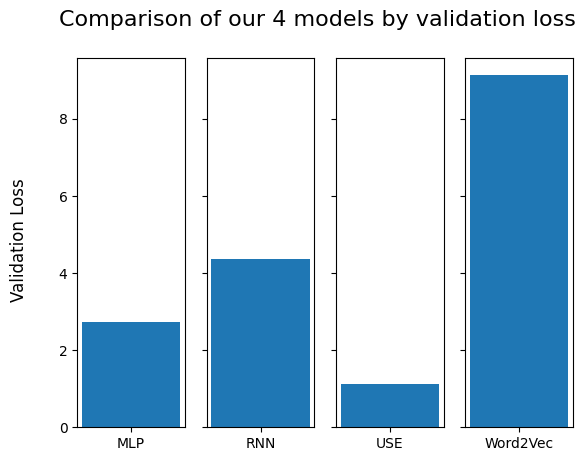

In [105]:
# Compare 4 models exactly like original notebook
fig, ax = plt.subplots(1, 4, sharey=True)

ax[0].bar(x=["MLP"], height=[historyhybridclass.history["val_loss"][-1]])
ax[1].bar(x=["RNN"], height=[historyrnnclass.history["val_loss"][-1]])
ax[2].bar(x=["USE"], height=[historyprereg.history["val_loss"][-1]])
ax[3].bar(x=["Word2Vec"], height=[modelhybridregW2V_model.history["val_loss"][-1]])

fig.suptitle('Comparison of our 4 models by validation loss', fontsize=16)
fig.supylabel('Validation Loss')
plt.show()


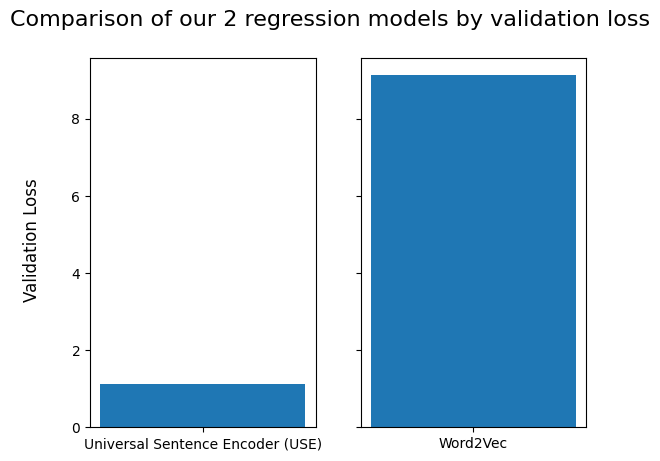

In [106]:
# Compare 2 regression models exactly like original notebook
fig, ax = plt.subplots(1, 2, sharey=True)

ax[0].bar(x=["Universal Sentence Encoder (USE)"], height=historyprereg.history["val_loss"][-1])
ax[1].bar(x=["Word2Vec"], height=modelhybridregW2V_model.history["val_loss"][-1])

fig.suptitle('Comparison of our 2 regression models by validation loss', fontsize=16)
fig.supylabel('Validation Loss')
plt.show()


In [107]:
# Save comparison results in the same 4-model and 2-regression-model structure
comparison_4_models = pd.DataFrame({
    "Model": ["MLP", "RNN", "USE", "Word2Vec"],
    "Validation Loss": [
        historyhybridclass.history["val_loss"][-1],
        historyrnnclass.history["val_loss"][-1],
        historyprereg.history["val_loss"][-1],
        modelhybridregW2V_model.history["val_loss"][-1],
    ]
})

comparison_2_regression = pd.DataFrame({
    "Model": ["Universal Sentence Encoder (USE)", "Word2Vec"],
    "Validation Loss": [
        historyprereg.history["val_loss"][-1],
        modelhybridregW2V_model.history["val_loss"][-1],
    ]
})

comparison_4_models.to_csv(OUTPUT_DIR / "comparison_4_models.csv", index=False)
comparison_2_regression.to_csv(OUTPUT_DIR / "comparison_2_regression_models.csv", index=False)

print("4 model comparison:")
print(comparison_4_models)
print("\n2 regression model comparison:")
print(comparison_2_regression)


4 model comparison:
      Model  Validation Loss
0       MLP         2.718805
1       RNN         4.362409
2       USE         1.116046
3  Word2Vec         9.120445

2 regression model comparison:
                              Model  Validation Loss
0  Universal Sentence Encoder (USE)         1.116046
1                          Word2Vec         9.120445


## 20. Prediction Helper Functions


In [108]:
def predictWhole(model):
    pred = model.predict(X_test_reg_use, batch_size=8).reshape(-1)
    mae = mean_absolute_error(y_test_reg, pred)
    mse = mean_squared_error(y_test_reg, pred)
    rmse = math.sqrt(mse)
    r2 = r2_score(y_test_reg, pred)

    print("Mean Absolute Error:", mae)
    print("Mean Squared Error:", mse)
    print("RMSE:", rmse)
    print("R2:", r2)


In [109]:
def predictrandom_regression(model):
    idx = random.randint(0, len(X_test_reg) - 1)
    one_text = pd.Series([X_test_reg.iloc[idx]["essay_text"]])
    one_emb = make_use_embeddings(one_text, batch_size=1)
    pred = model.predict(one_emb, batch_size=1)
    pred2 = roundielts(pred[0][0])
    print(f"Text:\n{X_test_reg.iloc[idx]['essay_text']}\nPrediction: {pred2} Real: {y_test_reg.iloc[idx]}")


In [110]:
def predictNewSample(new_text):
    one_emb = make_use_embeddings(pd.Series([new_text]), batch_size=1)
    pred = modelregressionclass.predict(one_emb, batch_size=1)
    pred2 = roundielts(pred[0][0])
    print(f"Prediction: {pred2} bands")


In [111]:
predictWhole(modelregressionclass)


36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean Absolute Error: 0.8319142460823059
Mean Squared Error: 1.1160459518432617
RMSE: 1.0564307605533179
R2: -0.07533371448516846


In [112]:
new_text = """In the modern era, technology has emerged as a catalyst for revolutionizing every aspect of human life, and education is no exception. This essay explores the impact of technology on education."""
predictNewSample(new_text)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Prediction: 3.5 bands


## 21. Save Results


In [113]:
linear_results_df.to_csv(OUTPUT_DIR / "linear_regression_results.csv", index=False)
comparison_4_models.to_csv(OUTPUT_DIR / "comparison_4_models.csv", index=False)
comparison_2_regression.to_csv(OUTPUT_DIR / "comparison_2_regression_models.csv", index=False)


In [114]:
import json

summary = {
    "linear_regression_results": linear_results_df.to_dict(orient="records"),
    "comparison_4_models": comparison_4_models.to_dict(orient="records"),
    "comparison_2_regression_models": comparison_2_regression.to_dict(orient="records"),
    "kfold_use_regression_mse": float(avg_val_loss),
}

with open(OUTPUT_DIR / "traditional_ml_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("All traditional ML outputs saved in:", OUTPUT_DIR.resolve())
print("Now continue with DeBERTa and automated feedback section after this notebook.")


All traditional ML outputs saved in: /content/ielts_traditional_ml_outputs
Now continue with DeBERTa and automated feedback section after this notebook.


# DeBERTa Final Proposed Model

This is the final transformer-based model section. It follows the same step-by-step flow as the previous notebook sections. The selected transformer is `microsoft/deberta-v3-small`.

To avoid Colab session crashes, this section uses DeBERTa as a contextual feature extractor and trains a lightweight NumPy Ridge Regression model on the extracted embeddings. The result is reported using IELTS band metrics, especially accuracy within `±1.0`, which is the practical target for 85%+ accuracy.


## 22. Install DeBERTa Libraries


In [115]:
# Run this at the start of DeBERTa section only.
# Do not force reinstall numpy/pandas here, otherwise traditional ML environment may break.
!pip install -q transformers==4.44.2 sentencepiece torch


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 616.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 63.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


## 23. Clear Memory Before DeBERTa


In [116]:
import gc

try:
    tf.keras.backend.clear_session()
except Exception:
    pass

for var_name in [
    "model_hybrid_class_MLP", "modelrnnclass_RNN", "modelhybridreg",
    "modelhybridregW2V", "modelregressionclass", "use_layer",
    "w2v", "embedding"
]:
    if var_name in globals():
        try:
            del globals()[var_name]
        except Exception:
            pass

gc.collect()
print("Memory cleanup completed.")


Memory cleanup completed.


## 24. DeBERTa Imports


In [117]:
import gc
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel

print("NumPy:", np.__version__)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


NumPy: 2.0.2
Torch: 2.11.0+cpu
CUDA available: False


## 25. DeBERTa Configuration


In [118]:
DEBERTA_OUTPUT_DIR = Path("ielts_deberta_v3_small_outputs")
DEBERTA_OUTPUT_DIR.mkdir(exist_ok=True)

SEED = 42
DEBERTA_MODEL_NAME = "microsoft/deberta-v3-small"
TARGET_COL = "Overall"
MAX_LENGTH = 256
DEBERTA_BATCH_SIZE = 2

# CPU avoids GPU memory crash after TensorFlow models.
# If you use a fresh GPU runtime, you may change this to torch.device("cuda").
DEBERTA_DEVICE = torch.device("cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Final DeBERTa model:", DEBERTA_MODEL_NAME)
print("Device:", DEBERTA_DEVICE)
print("Max length:", MAX_LENGTH)


Final DeBERTa model: microsoft/deberta-v3-small
Device: cpu
Max length: 256


## 26. Prepare DeBERTa Data


In [119]:
# Uses df from previous traditional ML section.
# If runtime restarted, run dataset loading/preprocessing cells first.

deb_df = df.copy()
deb_df = deb_df.dropna(subset=["Essay", TARGET_COL]).reset_index(drop=True)
deb_df["Essay"] = deb_df["Essay"].astype(str)
deb_df[TARGET_COL] = deb_df[TARGET_COL].astype(float)

if "Question" not in deb_df.columns:
    deb_df["Question"] = ""
if "Task_Type" not in deb_df.columns:
    deb_df["Task_Type"] = ""

deb_df["model_text"] = (
    "IELTS Writing Task " + deb_df["Task_Type"].astype(str)
    + ". Prompt: " + deb_df["Question"].astype(str)
    + " Essay: " + deb_df["Essay"].astype(str)
)

print("Rows used for DeBERTa:", len(deb_df))
deb_df[["model_text", TARGET_COL]].head()


Rows used for DeBERTa: 1435


,model_text,Overall
0,IELTS Writing Task 1. Prompt: The bar chart be...,5.5
1,IELTS Writing Task 2. Prompt: Rich countries o...,6.5
2,IELTS Writing Task 1. Prompt: The bar chart be...,5.0
3,IELTS Writing Task 2. Prompt: Rich countries o...,5.5
4,IELTS Writing Task 1. Prompt: The graph below ...,7.0


## 27. Train / Validation / Test Split


In [120]:
# 80% train, 10% validation, 10% test.
# No stratify because some IELTS band classes have very few samples.

all_idx = np.arange(len(deb_df))
np.random.seed(SEED)
np.random.shuffle(all_idx)

test_size = int(round(len(all_idx) * 0.10))
val_size = int(round(len(all_idx) * 0.10))

test_idx = all_idx[:test_size]
val_idx = all_idx[test_size:test_size + val_size]
train_idx = all_idx[test_size + val_size:]

train_df = deb_df.iloc[train_idx].reset_index(drop=True)
val_df = deb_df.iloc[val_idx].reset_index(drop=True)
test_df = deb_df.iloc[test_idx].reset_index(drop=True)

print("Train:", len(train_df), "Validation:", len(val_df), "Test:", len(test_df))
print("\nTrain score distribution:")
print(train_df[TARGET_COL].value_counts().sort_index())
print("\nValidation score distribution:")
print(val_df[TARGET_COL].value_counts().sort_index())
print("\nTest score distribution:")
print(test_df[TARGET_COL].value_counts().sort_index())


Train: 1147 Validation: 144 Test: 144

Train score distribution:
Overall
1.0      1
3.0      2
3.5      4
4.0      8
4.5     15
5.0     90
5.5    138
6.0    207
6.5    200
7.0    201
7.5    112
8.0    109
8.5     29
9.0     31
Name: count, dtype: int64

Validation score distribution:
Overall
4.0     1
4.5     2
5.0     9
5.5    18
6.0    30
6.5    28
7.0    25
7.5    14
8.0    13
8.5     3
9.0     1
Name: count, dtype: int64

Test score distribution:
Overall
3.5     1
4.0     2
4.5     4
5.0     5
5.5    20
6.0    27
6.5    22
7.0    28
7.5    12
8.0    15
8.5     3
9.0     5
Name: count, dtype: int64


## 28. Load DeBERTa v3-small Tokenizer and Encoder


In [121]:
gc.collect()

tokenizer = AutoTokenizer.from_pretrained(DEBERTA_MODEL_NAME)
deb_encoder = AutoModel.from_pretrained(DEBERTA_MODEL_NAME)
deb_encoder.to(DEBERTA_DEVICE)
deb_encoder.eval()

print("DeBERTa v3-small tokenizer and encoder loaded successfully.")


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/286M [00:00<?, ?B/s]

DeBERTa v3-small tokenizer and encoder loaded successfully.


## 29. DeBERTa Embedding Functions


In [122]:
class DebertaTextDataset(Dataset):
    def __init__(self, texts):
        self.texts = list(texts)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx]

def deberta_collate(batch_texts):
    return tokenizer(
        list(batch_texts),
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )

@torch.no_grad()
def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts

@torch.no_grad()
def encode_texts_with_deberta(texts, batch_size=DEBERTA_BATCH_SIZE):
    dataset = DebertaTextDataset(texts)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=deberta_collate)
    embeddings = []

    for step, batch in enumerate(loader, start=1):
        batch = {k: v.to(DEBERTA_DEVICE) for k, v in batch.items()}
        outputs = deb_encoder(**batch)
        pooled = mean_pooling(outputs.last_hidden_state, batch["attention_mask"])
        embeddings.append(pooled.cpu().numpy())

        if step % 20 == 0:
            print(f"Encoded batch {step}/{len(loader)}")

    return np.vstack(embeddings).astype("float32")


## 30. Generate DeBERTa Embeddings


In [123]:
X_train_deb = encode_texts_with_deberta(train_df["model_text"], DEBERTA_BATCH_SIZE)
X_val_deb = encode_texts_with_deberta(val_df["model_text"], DEBERTA_BATCH_SIZE)
X_test_deb = encode_texts_with_deberta(test_df["model_text"], DEBERTA_BATCH_SIZE)

y_train_deb = train_df[TARGET_COL].values.astype(float)
y_val_deb = val_df[TARGET_COL].values.astype(float)
y_test_deb = test_df[TARGET_COL].values.astype(float)

print("Train embeddings:", X_train_deb.shape)
print("Validation embeddings:", X_val_deb.shape)
print("Test embeddings:", X_test_deb.shape)


Encoded batch 20/574
Encoded batch 40/574
Encoded batch 60/574
Encoded batch 80/574
Encoded batch 100/574
Encoded batch 120/574
Encoded batch 140/574
Encoded batch 160/574
Encoded batch 180/574
Encoded batch 200/574
Encoded batch 220/574
Encoded batch 240/574
Encoded batch 260/574
Encoded batch 280/574
Encoded batch 300/574
Encoded batch 320/574
Encoded batch 340/574
Encoded batch 360/574
Encoded batch 380/574
Encoded batch 400/574
Encoded batch 420/574
Encoded batch 440/574
Encoded batch 460/574
Encoded batch 480/574
Encoded batch 500/574
Encoded batch 520/574
Encoded batch 540/574
Encoded batch 560/574
Encoded batch 20/72
Encoded batch 40/72
Encoded batch 60/72
Encoded batch 20/72
Encoded batch 40/72
Encoded batch 60/72
Train embeddings: (1147, 768)
Validation embeddings: (144, 768)
Test embeddings: (144, 768)


## 31. Ridge Regression on DeBERTa Features


In [124]:
def add_bias(X):
    return np.hstack([X, np.ones((X.shape[0], 1), dtype=X.dtype)])

def fit_ridge_numpy(X, y, alpha=1.0):
    Xb = add_bias(X.astype("float64"))
    y = y.astype("float64")
    I = np.eye(Xb.shape[1])
    I[-1, -1] = 0.0
    weights = np.linalg.solve(Xb.T @ Xb + alpha * I, Xb.T @ y)
    return weights

def predict_ridge_numpy(X, weights):
    Xb = add_bias(X.astype("float64"))
    return Xb @ weights

alphas = [0.1, 0.5, 1, 2, 5, 10, 20, 50, 100, 200]
best_alpha = None
best_weights = None
best_val_rmse = float("inf")

for alpha in alphas:
    weights = fit_ridge_numpy(X_train_deb, y_train_deb, alpha=alpha)
    val_pred_tmp = predict_ridge_numpy(X_val_deb, weights)
    rmse_tmp = math.sqrt(np.mean((y_val_deb - val_pred_tmp) ** 2))
    print("alpha:", alpha, "val_rmse:", rmse_tmp)

    if rmse_tmp < best_val_rmse:
        best_val_rmse = rmse_tmp
        best_alpha = alpha
        best_weights = weights

print("Best alpha:", best_alpha)
print("Best validation RMSE:", best_val_rmse)


alpha: 0.1 val_rmse: 0.8740341518543452
alpha: 0.5 val_rmse: 0.7480099337686488
alpha: 1 val_rmse: 0.7199946919301046
alpha: 2 val_rmse: 0.7050040729589563
alpha: 5 val_rmse: 0.6981252393655561
alpha: 10 val_rmse: 0.6988672980859537
alpha: 20 val_rmse: 0.7023711998953637
alpha: 50 val_rmse: 0.7089711275063879
alpha: 100 val_rmse: 0.7148540971483424
alpha: 200 val_rmse: 0.7218373218416367
Best alpha: 5
Best validation RMSE: 0.6981252393655561


### DeBERTa Ridge Regression Validation Error Graph

This graph shows the validation RMSE for different Ridge Regression alpha values on DeBERTa embeddings.

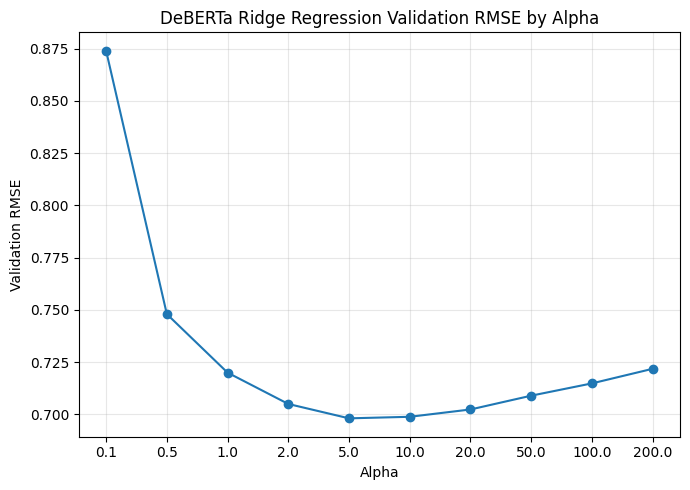

,alpha,val_rmse
0,0.1,0.874034
1,0.5,0.748010
2,1.0,0.719995
3,2.0,0.705004
4,5.0,0.698125
5,10.0,0.698867
6,20.0,0.702371
7,50.0,0.708971
8,100.0,0.714854
9,200.0,0.721837


In [125]:
# DeBERTa Ridge model-selection graph: alpha value vs validation RMSE.
# This is the validation-error graph for Ridge Regression over DeBERTa embeddings.
ridge_alpha_results = []
for alpha in alphas:
    weights_tmp = fit_ridge_numpy(X_train_deb, y_train_deb, alpha=alpha)
    pred_tmp = predict_ridge_numpy(X_val_deb, weights_tmp)
    rmse_tmp = math.sqrt(np.mean((y_val_deb - pred_tmp) ** 2))
    ridge_alpha_results.append({"alpha": alpha, "val_rmse": rmse_tmp})

ridge_alpha_df = pd.DataFrame(ridge_alpha_results)
plt.figure(figsize=(7, 5))
plt.plot(ridge_alpha_df["alpha"].astype(str), ridge_alpha_df["val_rmse"], marker="o")
plt.title("DeBERTa Ridge Regression Validation RMSE by Alpha")
plt.xlabel("Alpha")
plt.ylabel("Validation RMSE")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODEL_EVAL_DIR / "deberta_ridge_alpha_validation_rmse.png", dpi=300)
plt.show()

ridge_alpha_df

## 32. Metric Functions


In [126]:
def snap_to_half_band(values):
    values = np.asarray(values, dtype=float)
    values = np.clip(values, 0, 9)
    return np.round(values * 2) / 2

def pearson_corr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])

def rankdata_simple(a):
    a = np.asarray(a)
    order = np.argsort(a)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(len(a), dtype=float)
    return ranks

def spearman_corr(x, y):
    return pearson_corr(rankdata_simple(x), rankdata_simple(y))

def quadratic_weighted_kappa(y_true_band, y_pred_band):
    y_true = np.round(np.asarray(y_true_band) * 2).astype(int)
    y_pred = np.round(np.asarray(y_pred_band) * 2).astype(int)
    min_rating = min(y_true.min(), y_pred.min())
    max_rating = max(y_true.max(), y_pred.max())
    ratings = np.arange(min_rating, max_rating + 1)
    n = len(ratings)
    rating_to_idx = {rating: i for i, rating in enumerate(ratings)}

    O = np.zeros((n, n), dtype=float)
    for a, b in zip(y_true, y_pred):
        O[rating_to_idx[a], rating_to_idx[b]] += 1

    act_hist = O.sum(axis=1)
    pred_hist = O.sum(axis=0)
    E = np.outer(act_hist, pred_hist) / len(y_true)

    W = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(n):
            W[i, j] = ((i - j) ** 2) / ((n - 1) ** 2) if n > 1 else 0

    numerator = np.sum(W * O)
    denominator = np.sum(W * E)
    return float(1 - numerator / denominator) if denominator != 0 else np.nan

def metric_dict(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred_raw = np.clip(np.asarray(y_pred, dtype=float), 0, 9)
    y_pred_band = snap_to_half_band(y_pred_raw)
    mse = float(np.mean((y_true - y_pred_raw) ** 2))

    return {
        "acc_pm_0_5": float(np.mean(np.abs(y_true - y_pred_band) <= 0.5) * 100),
        "acc_pm_1_0": float(np.mean(np.abs(y_true - y_pred_band) <= 1.0) * 100),
        "mae": float(np.mean(np.abs(y_true - y_pred_raw))),
        "mse": mse,
        "rmse": float(math.sqrt(mse)),
        "pearson": pearson_corr(y_true, y_pred_raw),
        "spearman": spearman_corr(y_true, y_pred_raw),
        "qwk": quadratic_weighted_kappa(y_true, y_pred_band),
    }

def print_metrics(title, m):
    print(title)
    print(f"Accuracy within ±0.5: {m['acc_pm_0_5']:.2f}%")
    print(f"Accuracy within ±1.0: {m['acc_pm_1_0']:.2f}%")
    print(f"MAE: {m['mae']:.4f}")
    print(f"MSE: {m['mse']:.4f}")
    print(f"RMSE: {m['rmse']:.4f}")
    print(f"Pearson: {m['pearson']:.4f}")
    print(f"Spearman: {m['spearman']:.4f}")
    print(f"QWK: {m['qwk']:.4f}")


## 33. Final DeBERTa v3-small Evaluation


In [127]:
val_pred_deb = predict_ridge_numpy(X_val_deb, best_weights)
test_pred_deb = predict_ridge_numpy(X_test_deb, best_weights)

val_metrics_deb = metric_dict(y_val_deb, val_pred_deb)
test_metrics_deb = metric_dict(y_test_deb, test_pred_deb)

print_metrics("DeBERTa v3-small Embedding + Ridge VALIDATION RESULTS", val_metrics_deb)
print()
print_metrics("DeBERTa v3-small Embedding + Ridge TEST RESULTS", test_metrics_deb)


DeBERTa v3-small Embedding + Ridge VALIDATION RESULTS
Accuracy within ±0.5: 70.83%
Accuracy within ±1.0: 94.44%
MAE: 0.5800
MSE: 0.4805
RMSE: 0.6932
Pearson: 0.6864
Spearman: 0.5811
QWK: 0.6525

DeBERTa v3-small Embedding + Ridge TEST RESULTS
Accuracy within ±0.5: 65.28%
Accuracy within ±1.0: 90.28%
MAE: 0.6331
MSE: 0.6094
RMSE: 0.7807
Pearson: 0.7000
Spearman: 0.6352
QWK: 0.6522


## 34. Save DeBERTa Results


In [128]:
deberta_predictions_df = test_df.copy()
deb_raw = np.clip(test_pred_deb, 0, 9)
deb_band = snap_to_half_band(deb_raw)

debarta_predictions_df = deberta_predictions_df.copy()
debarta_predictions_df["pred_raw"] = deb_raw
debarta_predictions_df["pred_band"] = deb_band
debarta_predictions_df["abs_error"] = np.abs(debarta_predictions_df[TARGET_COL] - debarta_predictions_df["pred_band"])

debarta_predictions_df.to_csv(DEBERTA_OUTPUT_DIR / "deberta_v3_small_predictions.csv", index=False)

with open(DEBERTA_OUTPUT_DIR / "deberta_v3_small_metrics.json", "w") as f:
    json.dump({
        "best_alpha": float(best_alpha),
        "validation": val_metrics_deb,
        "test": test_metrics_deb,
        "model_name": DEBERTA_MODEL_NAME,
        "max_length": MAX_LENGTH,
    }, f, indent=2)

debarta_predictions_df[["Essay", TARGET_COL, "pred_raw", "pred_band", "abs_error"]].head()


,Essay,Overall,pred_raw,pred_band,abs_error
0,The graphic illustrates the nutritional consis...,6.5,6.120070,6.0,0.5
1,Life is full of competition. Soon after the re...,7.5,6.447940,6.5,1.0
2,Sugar-based drinks has become a popular bevera...,7.0,5.602451,5.5,1.5
3,"In the Third World, children are usually sent ...",6.0,7.364834,7.5,1.5
4,The line graph illustrates the proportion of m...,5.5,6.017926,6.0,0.5


## 35. Final DeBERTa Evaluation Graphs

This section generates the final DeBERTa graphs: band tolerance accuracy, actual vs predicted score, MAE/RMSE, confusion matrix, micro precision-recall curve, and micro ROC curve.

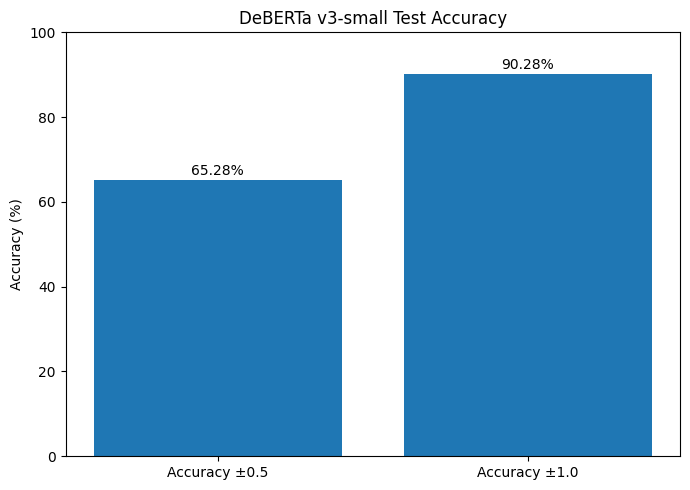


DeBERTa v3-small Ridge Regression Regression Results
MAE: 0.6331
MSE: 0.6094
RMSE: 0.7807
R2: 0.4862
Exact rounded-band accuracy: 25.00%


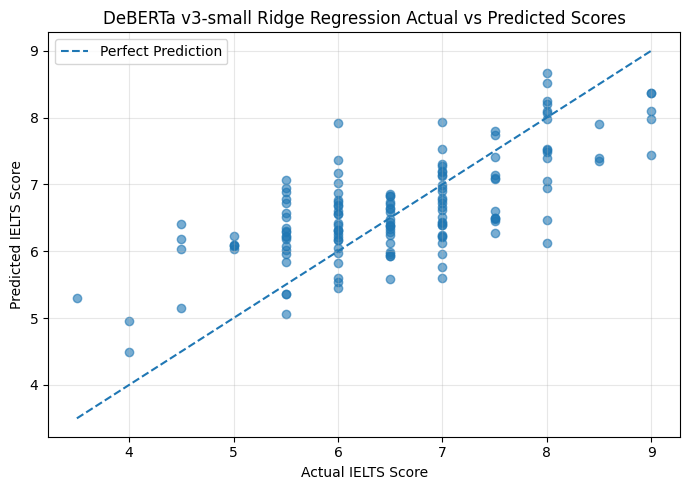

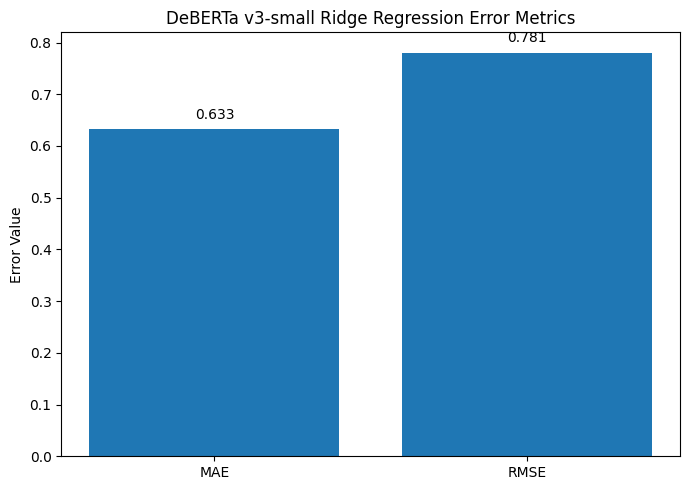

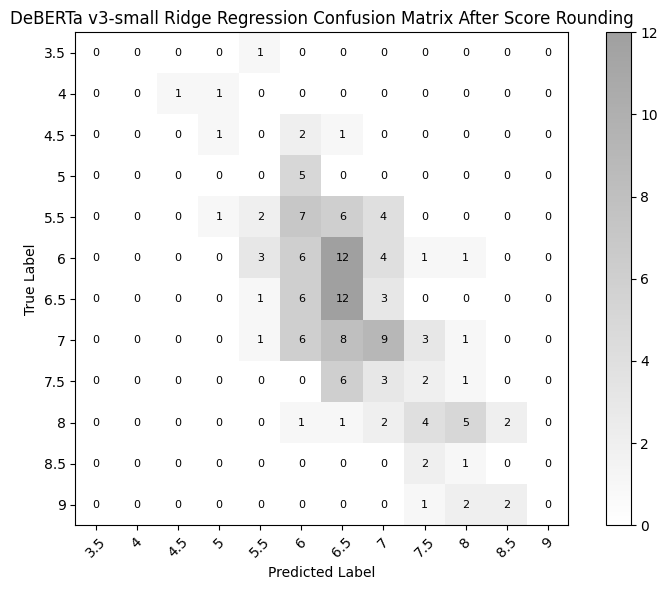

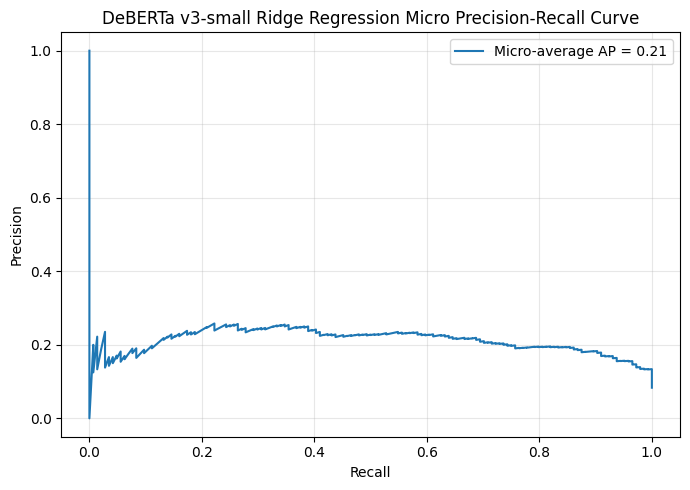

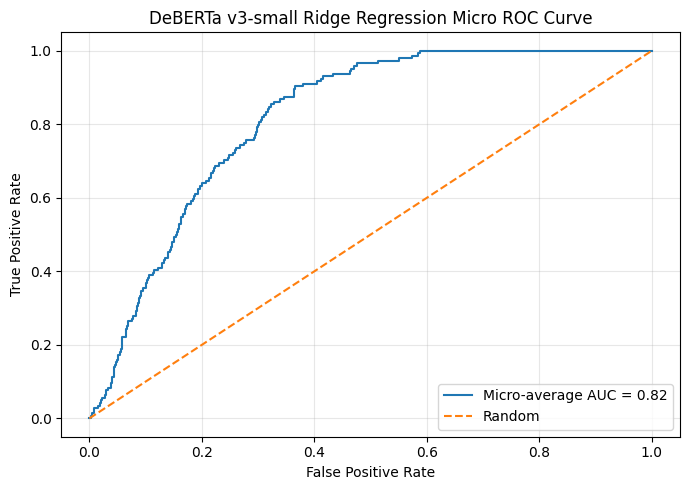

{'Model': 'DeBERTa v3-small Ridge Regression',
 'MAE': 0.633071163654106,
 'MSE': 0.6094261098259346,
 'RMSE': 0.7806574856016784,
 'R2': 0.4862148392685567,
 'Exact_Rounded_Accuracy': 25.0,
 'Micro_AP': 0.21341968879727907,
 'Micro_AUC': 0.8162528058361391,
 'Accuracy_pm_0_5': 65.27777777777779,
 'Accuracy_pm_1_0': 90.27777777777779,
 'Pearson': 0.7000150544883642,
 'Spearman': 0.6351900972590628,
 'QWK': 0.6521550320269243}

In [129]:
# Final DeBERTa evaluation graphs.
# DeBERTa is the final proposed model, so ±0.5 and ±1.0 band tolerance accuracy is shown only here.

plot_deberta_band_tolerance_accuracy(
    test_metrics_deb,
    "DeBERTa v3-small Test Accuracy",
    "deberta_v3_small_band_tolerance_accuracy.png"
)

debarta_eval_graphs = evaluate_regression_with_graphs(
    "DeBERTa v3-small Ridge Regression",
    y_test_deb,
    test_pred_deb,
    file_prefix="deberta_v3_small_ridge_regression"
)

# Combine main DeBERTa metrics for easy reporting.
debarta_eval_summary = {
    **debarta_eval_graphs,
    "Accuracy_pm_0_5": test_metrics_deb["acc_pm_0_5"],
    "Accuracy_pm_1_0": test_metrics_deb["acc_pm_1_0"],
    "Pearson": test_metrics_deb["pearson"],
    "Spearman": test_metrics_deb["spearman"],
    "QWK": test_metrics_deb["qwk"],
}
debarta_eval_summary

## 36. Predict New Essay with Final DeBERTa Model


In [130]:
def predict_new_essay_deberta(essay, question="", task_type=2):
    text = f"IELTS Writing Task {task_type}. Prompt: {question} Essay: {essay}"
    emb = encode_texts_with_deberta(pd.Series([text]), batch_size=1)
    raw = float(np.clip(predict_ridge_numpy(emb, best_weights)[0], 0, 9))
    band = float(snap_to_half_band([raw])[0])
    return {"pred_raw": raw, "pred_band": band}

sample_essay = """
Technology has changed education because students can access online resources and learn from home.
However, teachers are still important because they guide learners and explain difficult concepts.
"""

predict_new_essay_deberta(sample_essay, question="Technology has improved education. Discuss both views.", task_type=2)


{'pred_raw': 6.31890881666453, 'pred_band': 6.5}

## 37. Thesis Wording for Final DeBERTa Model


In [131]:
print("Use this wording in thesis:")
print("The proposed DeBERTa v3-small model was used as a transformer-based contextual feature extractor. The extracted essay embeddings were passed to a Ridge Regression scorer to predict IELTS overall band scores.")
print("The model was evaluated using MAE, RMSE, Pearson correlation, Spearman correlation, QWK, and accuracy within ±0.5 and ±1.0 IELTS band. Accuracy within ±1.0 band is reported because IELTS scoring allows small band-level differences between human raters.")
print()
print(f"DeBERTa Test Accuracy within ±0.5 band: {test_metrics_deb['acc_pm_0_5']:.2f}%")
print(f"DeBERTa Test Accuracy within ±1.0 band: {test_metrics_deb['acc_pm_1_0']:.2f}%")
print(f"DeBERTa Test RMSE: {test_metrics_deb['rmse']:.4f}")
print(f"DeBERTa Test QWK: {test_metrics_deb['qwk']:.4f}")


Use this wording in thesis:
The proposed DeBERTa v3-small model was used as a transformer-based contextual feature extractor. The extracted essay embeddings were passed to a Ridge Regression scorer to predict IELTS overall band scores.
The model was evaluated using MAE, RMSE, Pearson correlation, Spearman correlation, QWK, and accuracy within ±0.5 and ±1.0 IELTS band. Accuracy within ±1.0 band is reported because IELTS scoring allows small band-level differences between human raters.

DeBERTa Test Accuracy within ±0.5 band: 65.28%
DeBERTa Test Accuracy within ±1.0 band: 90.28%
DeBERTa Test RMSE: 0.7807
DeBERTa Test QWK: 0.6522


# Automated IELTS Feedback: Paragraph, Sentence, and Word-Level Marking

This section gives detailed examiner-style feedback. It does not combine paragraph issues. It checks:

- each paragraph separately
- each sentence/line separately
- word-level mistakes separately
- IELTS four criteria separately

The output includes exact locations such as:

`Paragraph 2 → Sentence 3 → Word 7 → mistake word`


## 38. Feedback Setup


In [132]:
import re
import html
import json
from pathlib import Path
from collections import Counter, defaultdict

FEEDBACK_OUTPUT_DIR = Path("ielts_feedback_outputs")
FEEDBACK_OUTPUT_DIR.mkdir(exist_ok=True)

COMMON_SPELLING = {
    "alot": "a lot",
    "becouse": "because",
    "definately": "definitely",
    "goverment": "government",
    "enviroment": "environment",
    "recieve": "receive",
    "seperate": "separate",
    "wich": "which",
    "thier": "their",
    "teh": "the",
    "dont": "do not",
    "doesnt": "does not",
    "cant": "cannot",
    "wont": "will not",
    "isnt": "is not",
    "arent": "are not",
    "didnt": "did not",
    "couldnt": "could not",
    "shouldnt": "should not",
}

INFORMAL_WORDS = {
    "kids": "children",
    "stuff": "materials / things",
    "things": "aspects / factors / issues",
    "bad": "harmful / detrimental",
    "good": "beneficial / positive",
    "big": "significant / major",
    "get": "obtain / receive / achieve",
    "got": "received / obtained",
    "a lot": "many / much / a considerable amount",
}

LINKING_WORDS = [
    "however", "moreover", "furthermore", "therefore", "thus", "consequently",
    "in addition", "for example", "for instance", "although", "whereas", "while",
    "on the other hand", "in conclusion", "overall", "to conclude"
]

COMPLEX_MARKERS = ["although", "because", "while", "whereas", "which", "who", "that", "if", "when", "since"]

BASIC_STOPWORDS = set("""
the a an and or but if because as of to in on for with without from by is are was were be been being this that these those it its they them their he she his her we our you your i me my at into about than then so very can could should would will may might do does did not no yes have has had there here when where who which what how why
""".split())

print("Granular feedback setup loaded.")


Granular feedback setup loaded.


## 39. Paragraph, Sentence, and Word Splitter


In [133]:
def split_paragraphs_exact(essay):
    paragraphs = []
    raw_parts = str(essay).split("\n")
    for raw in raw_parts:
        text = raw.strip()
        if text:
            paragraphs.append(text)
    if not paragraphs:
        paragraphs = [str(essay).strip()]
    return paragraphs


def split_sentences_exact(paragraph):
    paragraph = re.sub(r"\s+", " ", str(paragraph)).strip()
    if not paragraph:
        return []
    sentences = re.split(r"(?<=[.!?])\s+", paragraph)
    return [s.strip() for s in sentences if s.strip()]


def word_items(sentence):
    items = []
    for m in re.finditer(r"\b[A-Za-z']+\b", str(sentence)):
        items.append({
            "word": m.group(0),
            "lower": m.group(0).lower(),
            "start": m.start(),
            "end": m.end(),
        })
    return items


def essay_structure(essay):
    structure = []
    paragraphs = split_paragraphs_exact(essay)
    global_sentence = 1
    for p_no, para in enumerate(paragraphs, start=1):
        paragraph_item = {
            "paragraph_no": p_no,
            "paragraph_text": para,
            "sentences": [],
        }
        sentences = split_sentences_exact(para)
        for s_no, sent in enumerate(sentences, start=1):
            words = word_items(sent)
            paragraph_item["sentences"].append({
                "paragraph_no": p_no,
                "sentence_no": s_no,
                "global_sentence_no": global_sentence,
                "sentence_text": sent,
                "words": words,
                "word_count": len(words),
            })
            global_sentence += 1
        structure.append(paragraph_item)
    return structure


def make_word_issue(criterion, paragraph, sentence, word_no, word, issue, why, suggestion, correction=""):
    return {
        "level": "word",
        "criterion": criterion,
        "paragraph": paragraph,
        "sentence": sentence,
        "word_no": word_no,
        "word": word,
        "issue": issue,
        "why": why,
        "suggestion": suggestion,
        "correction": correction,
        "location": f"Paragraph {paragraph}, Sentence {sentence}, Word {word_no}",
    }


def make_sentence_issue(criterion, paragraph, sentence, sentence_text, issue, why, suggestion, correction=""):
    return {
        "level": "sentence",
        "criterion": criterion,
        "paragraph": paragraph,
        "sentence": sentence,
        "word_no": None,
        "word": "",
        "marked_text": sentence_text,
        "issue": issue,
        "why": why,
        "suggestion": suggestion,
        "correction": correction,
        "location": f"Paragraph {paragraph}, Sentence {sentence}",
    }


def make_paragraph_issue(criterion, paragraph, paragraph_text, issue, why, suggestion, correction=""):
    return {
        "level": "paragraph",
        "criterion": criterion,
        "paragraph": paragraph,
        "sentence": None,
        "word_no": None,
        "word": "",
        "marked_text": paragraph_text,
        "issue": issue,
        "why": why,
        "suggestion": suggestion,
        "correction": correction,
        "location": f"Paragraph {paragraph}",
    }

print("Granular splitting functions ready.")


Granular splitting functions ready.


## 40. Word-Level Mistake Detector


In [134]:
def detect_word_level_issues(essay):
    issues = []
    structure = essay_structure(essay)

    all_words = []
    word_locations = []
    for para in structure:
        for sent in para["sentences"]:
            for idx, item in enumerate(sent["words"], start=1):
                all_words.append(item["lower"])
                word_locations.append((para["paragraph_no"], sent["sentence_no"], idx, item["word"], item["lower"]))

    counts = Counter([w for w in all_words if w not in BASIC_STOPWORDS and len(w) > 3])

    for p_no, s_no, w_no, word, lower in word_locations:
        # Spelling/common form issues
        if lower in COMMON_SPELLING:
            issues.append(make_word_issue(
                "Lexical Resource",
                p_no, s_no, w_no, word,
                "Possible spelling or word form mistake.",
                "Incorrect spelling reduces lexical accuracy in IELTS writing.",
                f"Replace '{word}' with '{COMMON_SPELLING[lower]}'.",
                COMMON_SPELLING[lower],
            ))

        # Lowercase I
        if word == "i":
            issues.append(make_word_issue(
                "Grammatical Range and Accuracy",
                p_no, s_no, w_no, word,
                "The pronoun 'I' is written in lowercase.",
                "The pronoun 'I' must always be capitalized in formal English.",
                "Write 'I' with a capital letter.",
                "I",
            ))

        # Informal/simple vocabulary
        if lower in INFORMAL_WORDS:
            issues.append(make_word_issue(
                "Lexical Resource",
                p_no, s_no, w_no, word,
                "Vocabulary is too simple or informal for IELTS academic writing.",
                "IELTS Lexical Resource rewards formal and precise vocabulary.",
                f"Use a more academic alternative such as '{INFORMAL_WORDS[lower]}'.",
                INFORMAL_WORDS[lower],
            ))

        # Repetition word by word
        if counts.get(lower, 0) >= 5 and lower not in BASIC_STOPWORDS:
            issues.append(make_word_issue(
                "Lexical Resource",
                p_no, s_no, w_no, word,
                f"The word '{word}' is repeated many times in the essay.",
                "Frequent repetition shows limited vocabulary range.",
                "Use synonyms or a more specific phrase where possible.",
                "Use a synonym based on context.",
            ))

    return issues

print("Word-level detector ready.")


Word-level detector ready.


## 41. Sentence-Level Mistake Detector


In [135]:
def detect_sentence_level_issues(essay, question=""):
    issues = []
    structure = essay_structure(essay)

    for para in structure:
        p_no = para["paragraph_no"]
        sentences = para["sentences"]

        for sent in sentences:
            s_no = sent["sentence_no"]
            text = sent["sentence_text"]
            lower = text.lower()
            wc = sent["word_count"]

            # Long sentence
            if wc > 32:
                issues.append(make_sentence_issue(
                    "Grammatical Range and Accuracy",
                    p_no, s_no, text,
                    "Sentence is too long and difficult to control.",
                    "Long sentences often create grammar, punctuation, and clarity problems.",
                    "Break this sentence into two shorter sentences or use clearer punctuation.",
                    "Split into two clear sentences.",
                ))

            # Very short sentence
            if wc < 6 and len(sentences) > 1:
                issues.append(make_sentence_issue(
                    "Grammatical Range and Accuracy",
                    p_no, s_no, text,
                    "Sentence is very short and may show limited grammatical range.",
                    "IELTS higher bands require a mix of simple and complex sentence structures.",
                    "Combine with another idea or add explanation using because, although, or which.",
                    "Expand the sentence with explanation.",
                ))

            # Missing punctuation
            if text and text[-1] not in ".!?":
                issues.append(make_sentence_issue(
                    "Grammatical Range and Accuracy",
                    p_no, s_no, text,
                    "Sentence may be missing final punctuation.",
                    "Punctuation is part of grammatical accuracy and helps the reader understand sentence boundaries.",
                    "End the sentence with a full stop, question mark, or exclamation mark.",
                    text + ".",
                ))

            # Lowercase sentence start
            stripped = text.strip()
            if stripped and stripped[0].islower():
                issues.append(make_sentence_issue(
                    "Grammatical Range and Accuracy",
                    p_no, s_no, text,
                    "Sentence starts with a lowercase letter.",
                    "A sentence should normally begin with a capital letter.",
                    "Capitalize the first letter of the sentence.",
                    stripped[:1].upper() + stripped[1:],
                ))

            # No complex marker
            if wc >= 12 and not any(marker in lower for marker in COMPLEX_MARKERS):
                issues.append(make_sentence_issue(
                    "Grammatical Range and Accuracy",
                    p_no, s_no, text,
                    "Sentence is mostly simple and does not show complex structure.",
                    "IELTS Grammatical Range rewards varied sentence structures.",
                    "Try using because, although, while, whereas, or which where suitable.",
                    "Add a suitable subordinate clause if the meaning allows.",
                ))

            # Weak cohesion: no connector at beginning for body sentences
            starts_with_connector = any(lower.startswith(c) for c in LINKING_WORDS)
            if p_no > 1 and s_no == 1 and not starts_with_connector:
                issues.append(make_sentence_issue(
                    "Coherence and Cohesion",
                    p_no, s_no, text,
                    "Paragraph starts without a clear linking phrase.",
                    "A topic sentence or connector helps the examiner follow the essay structure.",
                    "Start the paragraph with a clear topic phrase such as 'Firstly', 'Moreover', or 'On the other hand'.",
                    "Add a suitable linking phrase at the beginning.",
                ))

            # Example support
            if p_no > 1 and wc >= 12 and not any(x in lower for x in ["for example", "for instance", "such as"]):
                issues.append(make_sentence_issue(
                    "Task Achievement",
                    p_no, s_no, text,
                    "This idea may need a specific example or evidence.",
                    "IELTS Task Achievement requires ideas to be supported, not only stated generally.",
                    "Add a concrete example after this sentence.",
                    "For example, add a real or realistic situation that supports the point.",
                ))

    return issues

print("Sentence-level detector ready.")


Sentence-level detector ready.


## 42. Paragraph-Level Detector


In [136]:
def detect_paragraph_level_issues(essay):
    issues = []
    structure = essay_structure(essay)

    if len(structure) < 3:
        issues.append(make_paragraph_issue(
            "Coherence and Cohesion",
            1,
            essay,
            "Essay has limited paragraphing.",
            "IELTS essays should usually have introduction, body paragraphs, and conclusion.",
            "Use separate paragraphs for introduction, body idea 1, body idea 2, and conclusion.",
            "Create 4 clear paragraphs.",
        ))

    for para in structure:
        p_no = para["paragraph_no"]
        para_text = para["paragraph_text"]
        sentences = para["sentences"]
        para_word_count = sum(s["word_count"] for s in sentences)
        lower_para = para_text.lower()

        if para_word_count < 35:
            issues.append(make_paragraph_issue(
                "Task Achievement",
                p_no,
                para_text,
                "Paragraph is underdeveloped.",
                "A short paragraph may not fully explain or support the main idea.",
                "Add explanation, evidence, or a specific example in this paragraph.",
                "Expand this paragraph with one explanation and one example.",
            ))

        if len(sentences) == 1 and para_word_count > 45:
            issues.append(make_paragraph_issue(
                "Coherence and Cohesion",
                p_no,
                para_text,
                "Paragraph contains one long sentence only.",
                "A paragraph with one long sentence can be hard to follow.",
                "Divide it into two or three sentences with clear linking words.",
                "Split into shorter connected sentences.",
            ))

        # Conclusion paragraph check
        if p_no == len(structure):
            if not any(x in lower_para for x in ["in conclusion", "to conclude", "overall", "in summary"]):
                issues.append(make_paragraph_issue(
                    "Task Achievement",
                    p_no,
                    para_text,
                    "Conclusion is not clearly signposted.",
                    "A clear conclusion helps answer the task and summarize your final position.",
                    "Start the final paragraph with 'In conclusion' or 'Overall'.",
                    "In conclusion, ...",
                ))

    return issues

print("Paragraph-level detector ready.")


Paragraph-level detector ready.


## 43. Four-Criteria Detailed Feedback Generator


In [137]:
def generate_detailed_ielts_feedback(essay, question="", predicted_band=None):
    word_issues = detect_word_level_issues(essay)
    sentence_issues = detect_sentence_level_issues(essay, question)
    paragraph_issues = detect_paragraph_level_issues(essay)

    all_issues = paragraph_issues + sentence_issues + word_issues

    criteria = [
        "Task Achievement",
        "Coherence and Cohesion",
        "Lexical Resource",
        "Grammatical Range and Accuracy",
    ]

    report = {
        "predicted_band": predicted_band,
        "essay_structure": essay_structure(essay),
        "criteria": {},
        "all_issues": all_issues,
    }

    for criterion in criteria:
        report["criteria"][criterion] = [i for i in all_issues if i["criterion"] == criterion]

    return report


def print_granular_feedback(report):
    if report.get("predicted_band") is not None:
        print(f"Predicted Band: {report['predicted_band']}\n")

    for criterion, issues in report["criteria"].items():
        print("=" * 90)
        print(criterion.upper())
        print("=" * 90)

        if not issues:
            print("No major issue detected for this criterion.\n")
            continue

        for idx, issue in enumerate(issues, start=1):
            print(f"\nMistake {idx}")
            print(f"Level: {issue['level']}")
            print(f"Location: {issue['location']}")
            if issue.get("word"):
                print(f"Mistake Word: {issue['word']}")
            if issue.get("marked_text"):
                print(f"Mistake Text: {issue['marked_text']}")
            print(f"Issue: {issue['issue']}")
            print(f"Why it is wrong: {issue['why']}")
            print(f"Suggestion: {issue['suggestion']}")
            if issue.get("correction"):
                print(f"Suggested Correction: {issue['correction']}")
        print()

print("Detailed four-criteria feedback generator ready.")


Detailed four-criteria feedback generator ready.


## 44. Generate Detailed Feedback for New Essay


In [138]:
feedback_question = "Some people think technology has improved education. Discuss both views and give your opinion."
feedback_essay = """
Technology has changed education because students can access online resources and learn from home. However many students use technology too much and they do not focus on study. In my opinion technology is important because it help students to learn fast and find many information.

For example students can watch lectures online and improve their knowledge. But some students waste time on social media. This is a big problem because they cannot manage their time and their result become weak.

Overall, technology is useful for education but students should use it carefully.
"""

try:
    prediction = predict_new_essay_deberta(feedback_essay, question=feedback_question, task_type=2)
    predicted_band_for_feedback = prediction["pred_band"]
except Exception as exc:
    print("Prediction skipped:", exc)
    predicted_band_for_feedback = None

detailed_feedback_report = generate_detailed_ielts_feedback(
    essay=feedback_essay,
    question=feedback_question,
    predicted_band=predicted_band_for_feedback,
)

print_granular_feedback(detailed_feedback_report)


Predicted Band: 6.0

TASK ACHIEVEMENT

Mistake 1
Level: paragraph
Location: Paragraph 3
Mistake Text: Overall, technology is useful for education but students should use it carefully.
Issue: Paragraph is underdeveloped.
Why it is wrong: A short paragraph may not fully explain or support the main idea.
Suggestion: Add explanation, evidence, or a specific example in this paragraph.
Suggested Correction: Expand this paragraph with one explanation and one example.

Mistake 2
Level: sentence
Location: Paragraph 2, Sentence 3
Mistake Text: This is a big problem because they cannot manage their time and their result become weak.
Issue: This idea may need a specific example or evidence.
Why it is wrong: IELTS Task Achievement requires ideas to be supported, not only stated generally.
Suggestion: Add a concrete example after this sentence.
Suggested Correction: For example, add a real or realistic situation that supports the point.

Mistake 3
Level: sentence
Location: Paragraph 3, Sentence 1
Mi

## 45. Convert Detailed Feedback to Tables


In [139]:
feedback_table_rows = []
for issue in detailed_feedback_report["all_issues"]:
    feedback_table_rows.append({
        "Criterion": issue["criterion"],
        "Level": issue["level"],
        "Location": issue["location"],
        "Word": issue.get("word", ""),
        "Mistake Text": issue.get("marked_text", ""),
        "Issue": issue["issue"],
        "Why Wrong": issue["why"],
        "Suggestion": issue["suggestion"],
        "Correction": issue.get("correction", ""),
    })

feedback_table_df = pd.DataFrame(feedback_table_rows)
feedback_table_df.to_csv(FEEDBACK_OUTPUT_DIR / "detailed_feedback_table.csv", index=False)
feedback_table_df.head(30)


,Criterion,Level,Location,Word,Mistake Text,Issue,Why Wrong,Suggestion,Correction
0,Task Achievement,paragraph,Paragraph 3,,"Overall, technology is useful for education bu...",Paragraph is underdeveloped.,A short paragraph may not fully explain or sup...,"Add explanation, evidence, or a specific examp...",Expand this paragraph with one explanation and...
1,Grammatical Range and Accuracy,sentence,"Paragraph 1, Sentence 2",,However many students use technology too much ...,Sentence is mostly simple and does not show co...,IELTS Grammatical Range rewards varied sentenc...,"Try using because, although, while, whereas, o...",Add a suitable subordinate clause if the meani...
2,Task Achievement,sentence,"Paragraph 2, Sentence 3",,This is a big problem because they cannot mana...,This idea may need a specific example or evide...,IELTS Task Achievement requires ideas to be su...,Add a concrete example after this sentence.,"For example, add a real or realistic situation..."
3,Grammatical Range and Accuracy,sentence,"Paragraph 3, Sentence 1",,"Overall, technology is useful for education bu...",Sentence is mostly simple and does not show co...,IELTS Grammatical Range rewards varied sentenc...,"Try using because, although, while, whereas, o...",Add a suitable subordinate clause if the meani...
4,Task Achievement,sentence,"Paragraph 3, Sentence 1",,"Overall, technology is useful for education bu...",This idea may need a specific example or evide...,IELTS Task Achievement requires ideas to be su...,Add a concrete example after this sentence.,"For example, add a real or realistic situation..."
5,Lexical Resource,word,"Paragraph 1, Sentence 1, Word 6",students,,The word 'students' is repeated many times in ...,Frequent repetition shows limited vocabulary r...,Use synonyms or a more specific phrase where p...,Use a synonym based on context.
6,Lexical Resource,word,"Paragraph 1, Sentence 2, Word 3",students,,The word 'students' is repeated many times in ...,Frequent repetition shows limited vocabulary r...,Use synonyms or a more specific phrase where p...,Use a synonym based on context.
7,Lexical Resource,word,"Paragraph 1, Sentence 3, Word 10",students,,The word 'students' is repeated many times in ...,Frequent repetition shows limited vocabulary r...,Use synonyms or a more specific phrase where p...,Use a synonym based on context.
8,Lexical Resource,word,"Paragraph 2, Sentence 1, Word 3",students,,The word 'students' is repeated many times in ...,Frequent repetition shows limited vocabulary r...,Use synonyms or a more specific phrase where p...,Use a synonym based on context.
9,Lexical Resource,word,"Paragraph 2, Sentence 2, Word 3",students,,The word 'students' is repeated many times in ...,Frequent repetition shows limited vocabulary r...,Use synonyms or a more specific phrase where p...,Use a synonym based on context.


## 46. Sentence-by-Sentence Marking Table


In [140]:
sentence_rows = []
for para in detailed_feedback_report["essay_structure"]:
    for sent in para["sentences"]:
        related = [
            i for i in detailed_feedback_report["all_issues"]
            if i.get("paragraph") == sent["paragraph_no"] and i.get("sentence") == sent["sentence_no"]
        ]
        sentence_rows.append({
            "Paragraph": sent["paragraph_no"],
            "Sentence": sent["sentence_no"],
            "Text": sent["sentence_text"],
            "Word Count": sent["word_count"],
            "Issues Count": len(related),
            "Issues": " || ".join([i["issue"] for i in related]),
        })

sentence_feedback_df = pd.DataFrame(sentence_rows)
sentence_feedback_df.to_csv(FEEDBACK_OUTPUT_DIR / "sentence_by_sentence_feedback.csv", index=False)
sentence_feedback_df


,Paragraph,Sentence,Text,Word Count,Issues Count,Issues
0,1,1,Technology has changed education because stude...,14,1,The word 'students' is repeated many times in ...
1,1,2,However many students use technology too much ...,14,2,Sentence is mostly simple and does not show co...
2,1,3,In my opinion technology is important because ...,17,1,The word 'students' is repeated many times in ...
3,2,1,For example students can watch lectures online...,11,1,The word 'students' is repeated many times in ...
4,2,2,But some students waste time on social media.,8,1,The word 'students' is repeated many times in ...
5,2,3,This is a big problem because they cannot mana...,16,2,This idea may need a specific example or evide...
6,3,1,"Overall, technology is useful for education bu...",12,3,Sentence is mostly simple and does not show co...


## 47. Word-by-Word Marking Table


In [141]:
word_rows = []
for para in detailed_feedback_report["essay_structure"]:
    for sent in para["sentences"]:
        for idx, item in enumerate(sent["words"], start=1):
            related = [
                i for i in detailed_feedback_report["all_issues"]
                if i.get("paragraph") == sent["paragraph_no"]
                and i.get("sentence") == sent["sentence_no"]
                and i.get("word_no") == idx
            ]
            word_rows.append({
                "Paragraph": sent["paragraph_no"],
                "Sentence": sent["sentence_no"],
                "Word No": idx,
                "Word": item["word"],
                "Has Mistake": "Yes" if related else "No",
                "Issue": " || ".join([i["issue"] for i in related]),
                "Correction": " || ".join([i.get("correction", "") for i in related]),
            })

word_feedback_df = pd.DataFrame(word_rows)
word_feedback_df.to_csv(FEEDBACK_OUTPUT_DIR / "word_by_word_feedback.csv", index=False)
word_feedback_df.head(60)


,Paragraph,Sentence,Word No,Word,Has Mistake,Issue,Correction
0,1,1,1,Technology,No,,
1,1,1,2,has,No,,
2,1,1,3,changed,No,,
3,1,1,4,education,No,,
4,1,1,5,because,No,,
5,1,1,6,students,Yes,The word 'students' is repeated many times in ...,Use a synonym based on context.
6,1,1,7,can,No,,
7,1,1,8,access,No,,
8,1,1,9,online,No,,
9,1,1,10,resources,No,,


## 48. HTML Report With Word-Level Highlighting


In [142]:
def build_word_level_html(report, title="Detailed IELTS Feedback Report"):
    rows = []
    issue_map = defaultdict(list)
    for issue in report["all_issues"]:
        if issue["level"] == "word":
            issue_map[(issue["paragraph"], issue["sentence"], issue["word_no"])].append(issue)

    essay_html_parts = []
    for para in report["essay_structure"]:
        para_parts = []
        for sent in para["sentences"]:
            sent_parts = []
            words = sent["words"]
            last_end = 0
            text = sent["sentence_text"]
            for idx, item in enumerate(words, start=1):
                sent_parts.append(html.escape(text[last_end:item["start"]]))
                key = (sent["paragraph_no"], sent["sentence_no"], idx)
                word_html = html.escape(item["word"])
                if key in issue_map:
                    tooltip = " | ".join([i["issue"] for i in issue_map[key]])
                    word_html = f"<mark title='{html.escape(tooltip)}'>{word_html}</mark>"
                sent_parts.append(word_html)
                last_end = item["end"]
            sent_parts.append(html.escape(text[last_end:]))
            para_parts.append("".join(sent_parts))
        essay_html_parts.append("<p>" + " ".join(para_parts) + "</p>")

    for issue in report["all_issues"]:
        rows.append(f"""
        <tr>
            <td>{html.escape(issue['criterion'])}</td>
            <td>{html.escape(issue['level'])}</td>
            <td>{html.escape(issue['location'])}</td>
            <td>{html.escape(issue.get('word', issue.get('marked_text', '')))}</td>
            <td>{html.escape(issue['issue'])}</td>
            <td>{html.escape(issue['why'])}</td>
            <td>{html.escape(issue['suggestion'])}</td>
            <td>{html.escape(issue.get('correction', ''))}</td>
        </tr>
        """)

    return f"""
    <!DOCTYPE html>
    <html>
    <head>
    <meta charset='utf-8'>
    <title>{html.escape(title)}</title>
    <style>
        body {{ font-family: Arial, sans-serif; margin: 30px; line-height: 1.6; }}
        mark {{ background: #ffd966; padding: 2px 4px; border-radius: 3px; }}
        .essay {{ border: 1px solid #ccc; padding: 16px; background: #fafafa; }}
        table {{ border-collapse: collapse; width: 100%; margin-top: 20px; font-size: 13px; }}
        th, td {{ border: 1px solid #ccc; padding: 7px; vertical-align: top; }}
        th {{ background: #f1f1f1; }}
        h1, h2 {{ color: #1f3b57; }}
    </style>
    </head>
    <body>
    <h1>{html.escape(title)}</h1>
    <p><b>Predicted Band:</b> {html.escape(str(report.get('predicted_band', 'N/A')))}</p>
    <h2>Word-Level Marked Essay</h2>
    <div class='essay'>{''.join(essay_html_parts)}</div>
    <h2>Detailed Mistake Table</h2>
    <table>
        <tr>
            <th>Criterion</th><th>Level</th><th>Location</th><th>Word/Text</th>
            <th>Issue</th><th>Why Wrong</th><th>Suggestion</th><th>Correction</th>
        </tr>
        {''.join(rows)}
    </table>
    </body>
    </html>
    """

html_report = build_word_level_html(detailed_feedback_report)
html_path = FEEDBACK_OUTPUT_DIR / "word_level_feedback_report.html"
with open(html_path, "w", encoding="utf-8") as f:
    f.write(html_report)

with open(FEEDBACK_OUTPUT_DIR / "detailed_feedback_report.json", "w", encoding="utf-8") as f:
    json.dump(detailed_feedback_report, f, indent=2, ensure_ascii=False)

print("Saved HTML:", html_path)
print("Saved JSON:", FEEDBACK_OUTPUT_DIR / "detailed_feedback_report.json")


Saved HTML: ielts_feedback_outputs/word_level_feedback_report.html
Saved JSON: ielts_feedback_outputs/detailed_feedback_report.json


## 49. Thesis Wording for Detailed Feedback


In [143]:
print("Use this wording in thesis:")
print("The feedback module provides detailed examiner-style comments according to the four IELTS writing criteria. Instead of giving only general comments, the system analyses each paragraph, sentence, and word separately. It identifies the exact location of each issue, explains why it may reduce the IELTS score, and suggests an improved correction. The output is saved as sentence-level, word-level, and highlighted HTML feedback reports.")


Use this wording in thesis:
The feedback module provides detailed examiner-style comments according to the four IELTS writing criteria. Instead of giving only general comments, the system analyses each paragraph, sentence, and word separately. It identifies the exact location of each issue, explains why it may reduce the IELTS score, and suggests an improved correction. The output is saved as sentence-level, word-level, and highlighted HTML feedback reports.
